In [23]:
"""
Fragment 1 — Data Loading
==========================
Custom CNN 6L Hybrid Pipeline — Feature Extraction + ML Classification

- Loads train, val and test data from disk
- Augmented folder already exists — no new augmentation
- Uses simple rescale 1/255 — custom CNN has no pretrained
  preprocessing requirements
- All three sets loaded here since feature extraction
  requires passing images through the trained CNN once
- shuffle=False on all sets — required for correct label
  alignment during feature extraction
- Features will be extracted in Fragment 2 and saved to disk
"""

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")   # shared augmented folder
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert os.path.exists(AUG_DIR), \
    f"Augmented folder not found: {AUG_DIR}"
assert os.path.exists(VALID_DIR), \
    f"Validation folder not found: {VALID_DIR}"
assert os.path.exists(TEST_DIR), \
    f"Test folder not found: {TEST_DIR}"

# ── Step 1: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str, test_dir: str):
    """
    Builds generators for all three sets.
    Custom CNN has no pretrained preprocessing so simple
    rescale to [0, 1] is applied — consistent across all
    three sets and matching the DL training pipeline.
    shuffle=False on all sets — critical for correct label
    alignment when extracting features batch by batch.
    """

    # ── Train generator ──
    train_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,    # must be False for feature extraction
    )

    # ── Val generator ──
    valid_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    # ── Test generator ──
    test_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    return train_generator, valid_generator, test_generator

# ── Step 2: Run and Summarise ─────────────────────────────────────────────────

train_generator, valid_generator, test_generator = build_generators(
    AUG_DIR, VALID_DIR, TEST_DIR
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Fragment 1 — Data Generators Ready")
print("=" * 60)
print(f"  Pipeline      : Custom CNN 6L + SVM / KNN (Hybrid)")
print(f"  Train source  : augmented/   (shared, no new aug)")
print(f"  Valid source  : val/")
print(f"  Test source   : test/")
print(f"  Preprocessing : rescale 1/255")
print(f"  Shuffle       : False on all sets (required for")
print(f"                  correct label alignment)")
print(f"  Train samples : {train_generator.samples}")
print(f"  Valid samples : {valid_generator.samples}")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes ({NUM_CLASSES})  : {CLASS_NAMES}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     train_generator, valid_generator and test_generator are ready.")
print("     Proceed to Fragment 2 — Custom CNN 6L Training & Feature Extraction.\n")

Found 8833 images belonging to 11 classes.
Found 644 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  Fragment 1 — Data Generators Ready
  Pipeline      : Custom CNN 6L + SVM / KNN (Hybrid)
  Train source  : augmented/   (shared, no new aug)
  Valid source  : val/
  Test source   : test/
  Preprocessing : rescale 1/255
  Shuffle       : False on all sets (required for
                  correct label alignment)
  Train samples : 8833
  Valid samples : 644
  Test samples  : 658
  Classes (11)  : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']
  Image size    : (224, 224)
  Batch size    : 32

  ✓ Fragment 1 complete.
     train_generator, valid_generator and test_generator are ready.
     Proceed to Fragment 2 — Custom CNN 6L Training & Feature Extraction.



In [24]:
"""
Fragment 2 — Custom CNN 6L Feature Extraction from Best Checkpoint
===================================================================
Custom CNN 6L Hybrid Pipeline — Feature Extraction + ML Classification

- Loads the best saved CNN 6L checkpoint by val accuracy
- Removes classification head — keeps convolutional base only
- Exposes Dense(128) as the 128-dimensional feature vector
- All layers frozen — used purely as feature extractor
- Passes all three sets through to extract features
- Features saved to disk as .npy files for reuse by
  Fragment 3 (SVM) and Fragment 4 (KNN)
- No retraining — reuses best DL run directly
"""

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

SAVE_DIR    = r"D:\Mold Studies\Models"
FEATURE_DIR = os.path.join(SAVE_DIR, "features", "custom_cnn6")
TOTAL_RUNS  = 5

os.makedirs(FEATURE_DIR, exist_ok=True)

# ── Step 1: Find Best Run by Val Accuracy from CSV Logs ───────────────────────

print("=" * 60)
print("  Step 1 — Finding Best CNN 6L Run by Val Accuracy")
print("=" * 60)

best_run_idx  = None
best_val_acc  = -1

for run_idx in range(1, TOTAL_RUNS + 1):

    # Run 1 log is named differently
    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR, "custom_cnn_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR, f"custom_cnn_run{run_idx}_log.csv")

    if not os.path.exists(csv_path):
        print(f"  ✗ Run {run_idx} — log not found: {csv_path}")
        continue

    log     = pd.read_csv(csv_path)
    val_acc = max(log["val_accuracy"])

    print(f"  Run {run_idx} — best val_accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_run_idx = run_idx

print(f"\n  ✓ Best run : Run {best_run_idx} "
      f"— val_accuracy = {best_val_acc:.4f}")

# ── Step 2: Load Best Checkpoint ──────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Loading Best CNN 6L Checkpoint")
print("=" * 60)

ckpt_name = f"custom_cnn_run{best_run_idx}_best.keras"
ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

assert os.path.exists(ckpt_path), \
    f"Checkpoint not found: {ckpt_path}\n" \
    f"Ensure CNN 6L DL pipeline Fragment 3b completed successfully."

full_model = tf.keras.models.load_model(ckpt_path)

print(f"  Loaded       : {ckpt_name}")
print(f"  Best run     : Run {best_run_idx}")
print(f"  Best val acc : {best_val_acc:.4f}")

# ── Step 3: Build Feature Extractor ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 3 — Building Feature Extractor")
print("=" * 60)

# Tap Dense(128) — the penultimate layer just before softmax
# This gives a 128-dimensional domain-specific feature vector
# learned entirely on mould/fruit data during DL training

feature_extractor = Model(
    inputs  = full_model.input,
    outputs = full_model.get_layer("dense_128").output,
    name    = "custom_cnn6_feature_extractor"
)

# Freeze all layers — fixed extractor for all SVM/KNN runs
feature_extractor.trainable = False

total_params  = feature_extractor.count_params()
frozen_params = sum(tf.size(w).numpy()
                    for w in feature_extractor.non_trainable_weights)

print(f"  Source model     : {ckpt_name}")
print(f"  Extractor output : Dense(128) — 128 features per image")
print(f"  Trained on       : mould/fruit dataset (not ImageNet)")
print(f"  Best run         : Run {best_run_idx} "
      f"(val_acc = {best_val_acc:.4f})")
print(f"  All layers frozen: ✓")
print(f"  Total params     : {total_params:,}")
print(f"  Frozen params    : {frozen_params:,}")
print("=" * 60)

# ── Step 4: Feature Extraction Function ──────────────────────────────────────

def extract_features(generator, extractor, set_name):
    """
    Passes all images through the CNN 6L feature extractor.
    Returns feature matrix X and label array y.
    Generator must have shuffle=False for correct alignment.
    Features saved to disk as .npy files.
    If features already exist on disk they are loaded
    instead of recomputed — safe to rerun.
    """

    feat_path  = os.path.join(FEATURE_DIR, f"X_{set_name}.npy")
    label_path = os.path.join(FEATURE_DIR, f"y_{set_name}.npy")

    if os.path.exists(feat_path) and os.path.exists(label_path):
        print(f"  ✓ {set_name:<8} — loading from disk")
        X = np.load(feat_path)
        y = np.load(label_path)
        return X, y

    print(f"  Extracting {set_name} features...")
    generator.reset()

    X = extractor.predict(
        generator,
        steps   = np.ceil(generator.samples / generator.batch_size),
        verbose = 1,
    )
    y = generator.classes

    np.save(feat_path,  X)
    np.save(label_path, y)
    print(f"  ✓ {set_name:<8} — saved to disk  shape: {X.shape}")

    return X, y

# ── Step 5: Extract All Three Sets ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 4 — Extracting Features")
print("=" * 60)
print(f"  Feature dir : {FEATURE_DIR}")
print(f"  Note        : if features already exist on disk")
print(f"                they will be loaded instead of")
print(f"                recomputed — safe to rerun\n")

X_train, y_train = extract_features(train_generator,
                                     feature_extractor, "train")
X_val,   y_val   = extract_features(valid_generator,
                                     feature_extractor, "val")
X_test,  y_test  = extract_features(test_generator,
                                     feature_extractor, "test")

# ── Step 6: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 5 — Feature Extraction Complete")
print("=" * 60)
print(f"  Architecture  : Custom CNN 6L (best DL checkpoint)")
print(f"  Source        : {ckpt_name}")
print(f"  Best val acc  : {best_val_acc:.4f}")
print(f"  Extractor     : Dense(128) — 128 features per image")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_val shape   : {X_val.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Features      : {X_train.shape[1]} per image")
print(f"  Classes       : {NUM_CLASSES}")
print(f"  Saved to      : {FEATURE_DIR}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete.")
print("     X_train, X_val, X_test, y_train, y_val, y_test are ready.")
print("     Best DL checkpoint reused — no retraining required.")
print("     Proceed to Fragment 3 — SVM Classification.\n")
print("     Fragment 4 — KNN Classification will reuse")
print("     the same features without reloading the CNN.\n")

  Step 1 — Finding Best CNN 6L Run by Val Accuracy
  Run 1 — best val_accuracy: 0.9656
  Run 2 — best val_accuracy: 0.6234
  Run 3 — best val_accuracy: 0.9578
  Run 4 — best val_accuracy: 0.9703
  Run 5 — best val_accuracy: 0.9672

  ✓ Best run : Run 4 — val_accuracy = 0.9703

  Step 2 — Loading Best CNN 6L Checkpoint
  Loaded       : custom_cnn_run4_best.keras
  Best run     : Run 4
  Best val acc : 0.9703

  Step 3 — Building Feature Extractor
  Source model     : custom_cnn_run4_best.keras
  Extractor output : Dense(128) — 128 features per image
  Trained on       : mould/fruit dataset (not ImageNet)
  Best run         : Run 4 (val_acc = 0.9703)
  All layers frozen: ✓
  Total params     : 26,011,168
  Frozen params    : 26,011,168

  Step 4 — Extracting Features
  Feature dir : D:\Mold Studies\Models\features\custom_cnn6
  Note        : if features already exist on disk
                they will be loaded instead of
                recomputed — safe to rerun

  Extracting train feat

  Fragment 3 — Custom CNN 6L + SVM  (5 Runs)
  Design         : each run uses its own CNN checkpoint
  Feature source : Dense(128) from custom_cnn_run{N}_best.keras
  Kernel         : linear
  C              : 1.0
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  Custom CNN 6L + SVM
  CNN checkpoint : custom_cnn_run1_best.keras
  SVM seed       : 27

  Loading checkpoint : custom_cnn_run1_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9656
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training SVM on CNN run 1 features...
  ✓ Training complete

  Run 1 Results
    CNN val_acc  : 0.9656
    SVM Accuracy : 0.9620
    Precision    : 0.9584
    Recall       : 0.9615
    Specificity  : 0.9962
    F1 Score     : 0.9597
    Mean AUC     : 0.9986


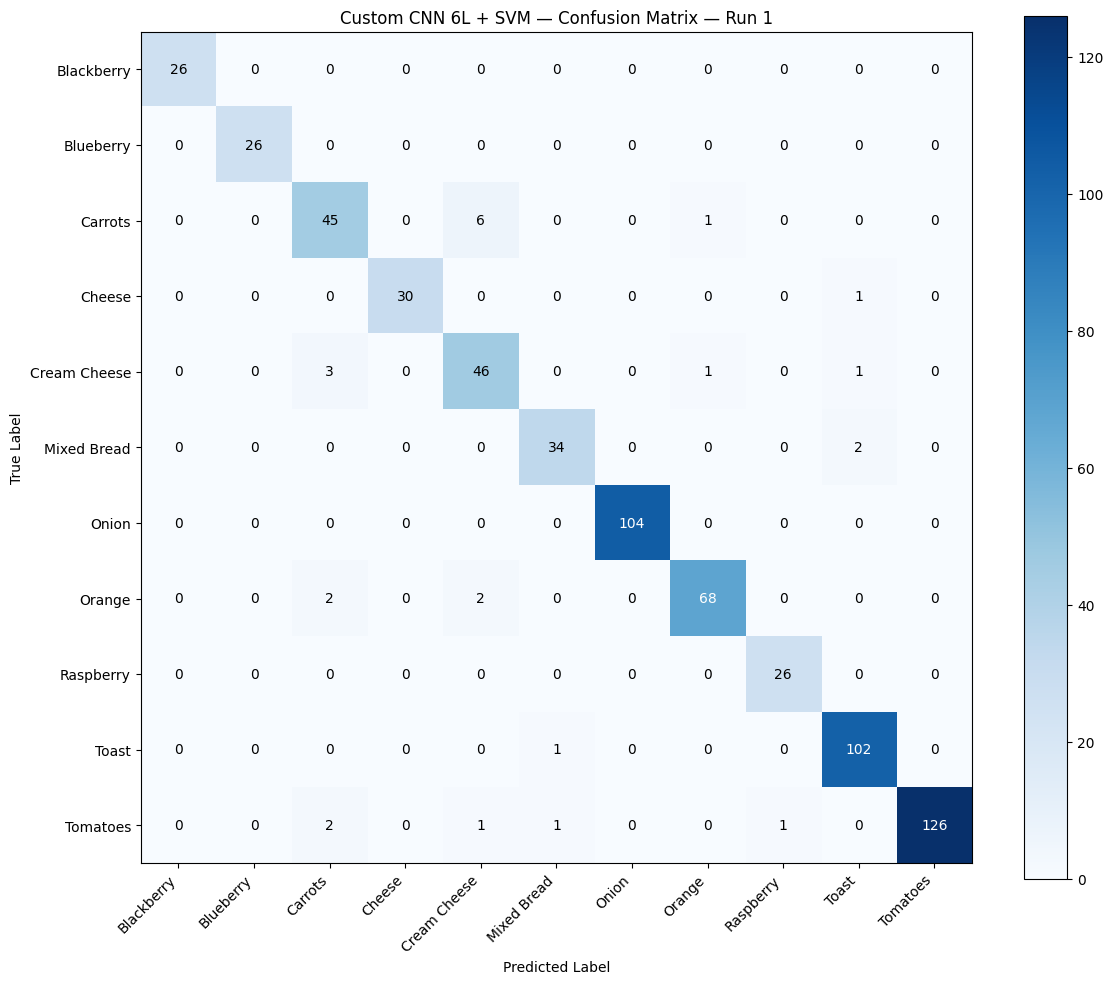

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_confusion_matrix_run1.png


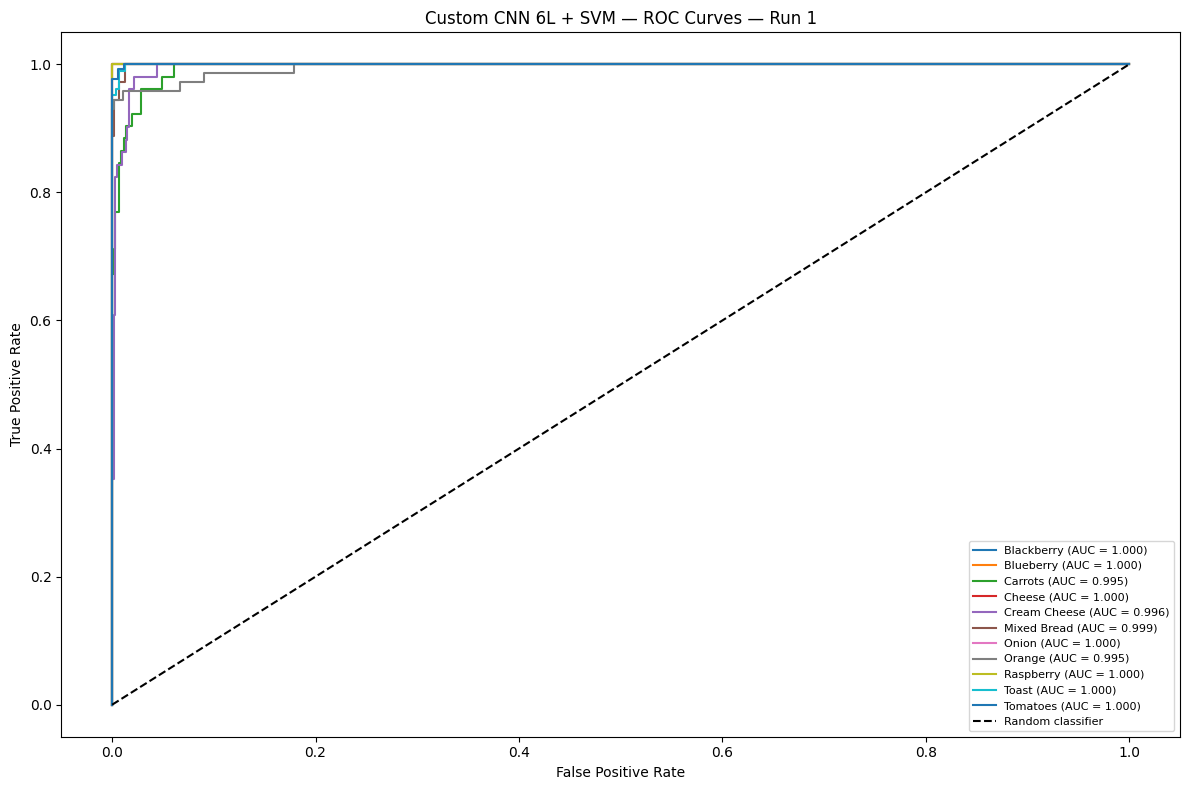

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_roc_curves_run1.png


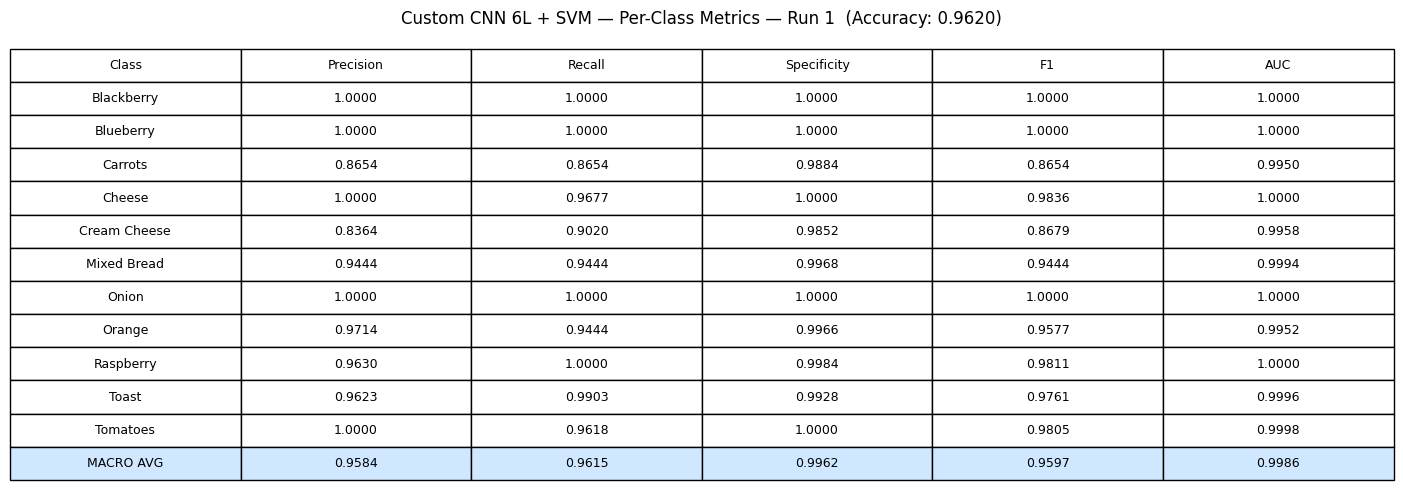

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_metrics_table_run1.png

  RUN 2 / 5  —  Custom CNN 6L + SVM
  CNN checkpoint : custom_cnn_run2_best.keras
  SVM seed       : 42

  Loading checkpoint : custom_cnn_run2_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.6234
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training SVM on CNN run 2 features...
  ✓ Training complete

  Run 2 Results
    CNN val_acc  : 0.6234
    SVM Accuracy : 0.6125
    Precision    : 0.7076
    Recall       : 0.7016
    Specificity  : 0.9586
    F1 Score     : 0.6697
    Mean AUC     : 0.9163


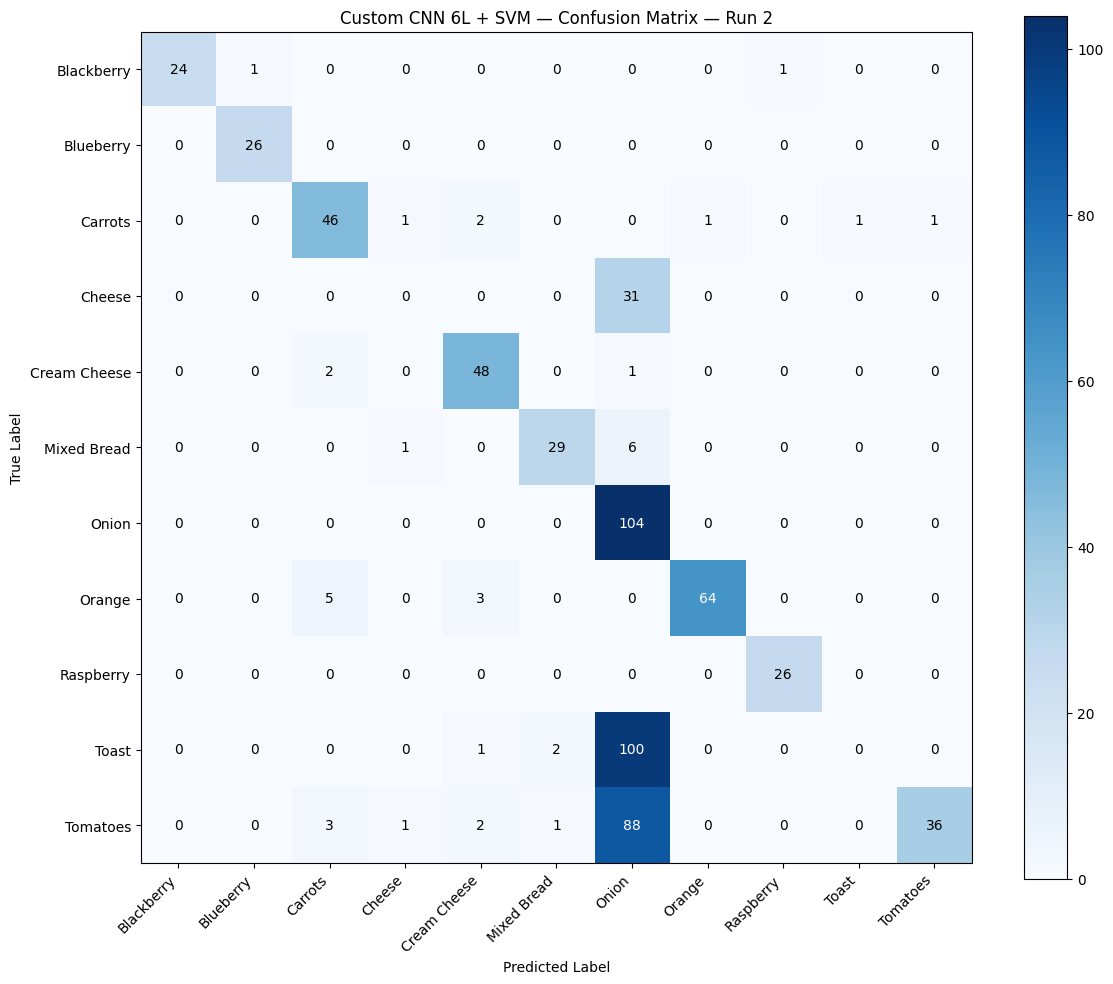

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_confusion_matrix_run2.png


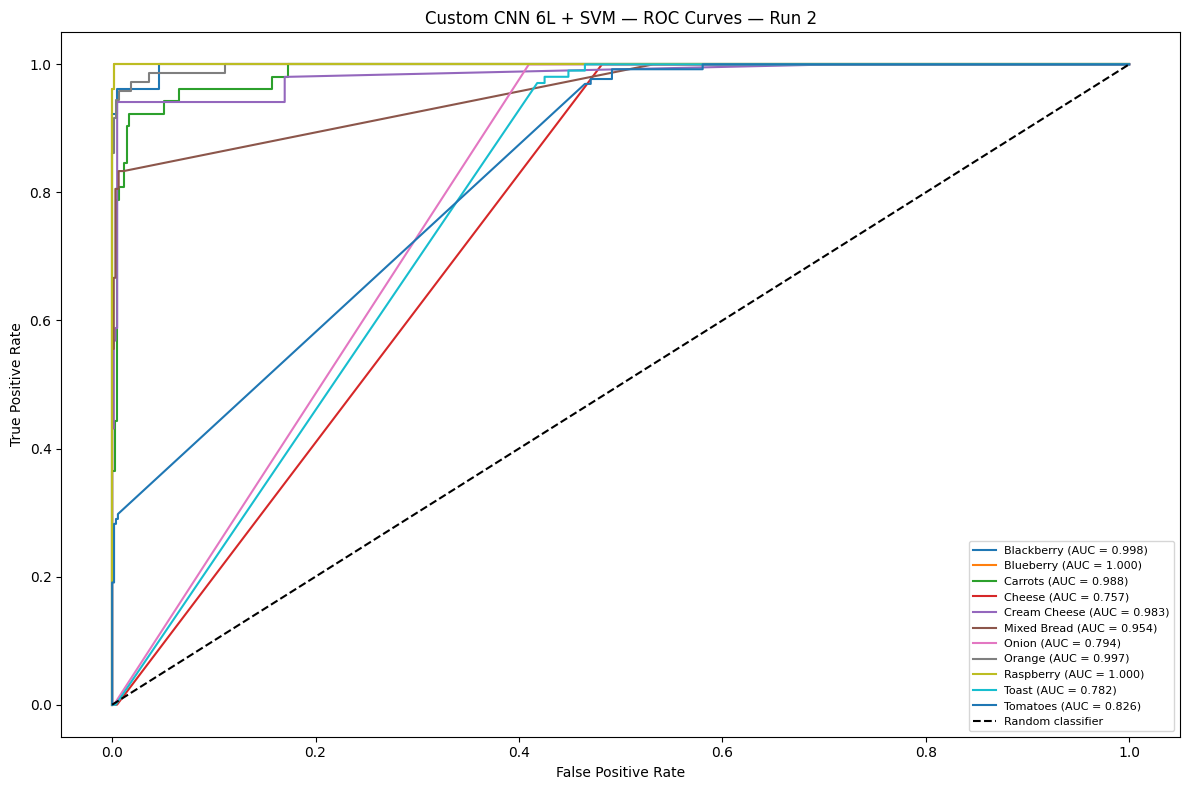

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_roc_curves_run2.png


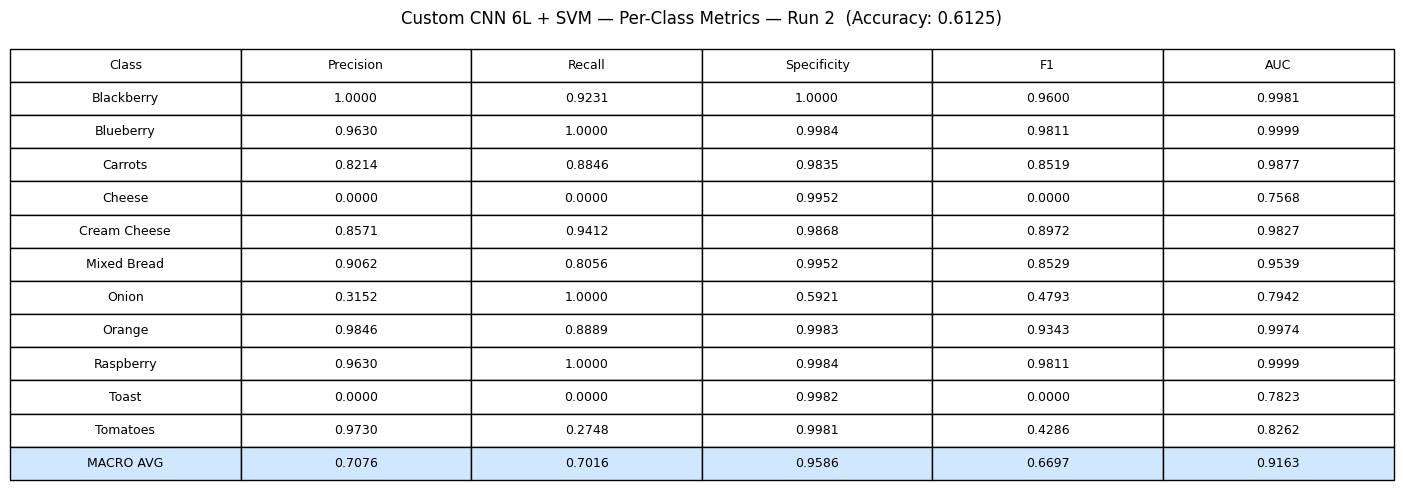

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_metrics_table_run2.png

  RUN 3 / 5  —  Custom CNN 6L + SVM
  CNN checkpoint : custom_cnn_run3_best.keras
  SVM seed       : 99

  Loading checkpoint : custom_cnn_run3_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9578
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training SVM on CNN run 3 features...
  ✓ Training complete

  Run 3 Results
    CNN val_acc  : 0.9578
    SVM Accuracy : 0.9529
    Precision    : 0.9476
    Recall       : 0.9552
    Specificity  : 0.9953
    F1 Score     : 0.9504
    Mean AUC     : 0.9976


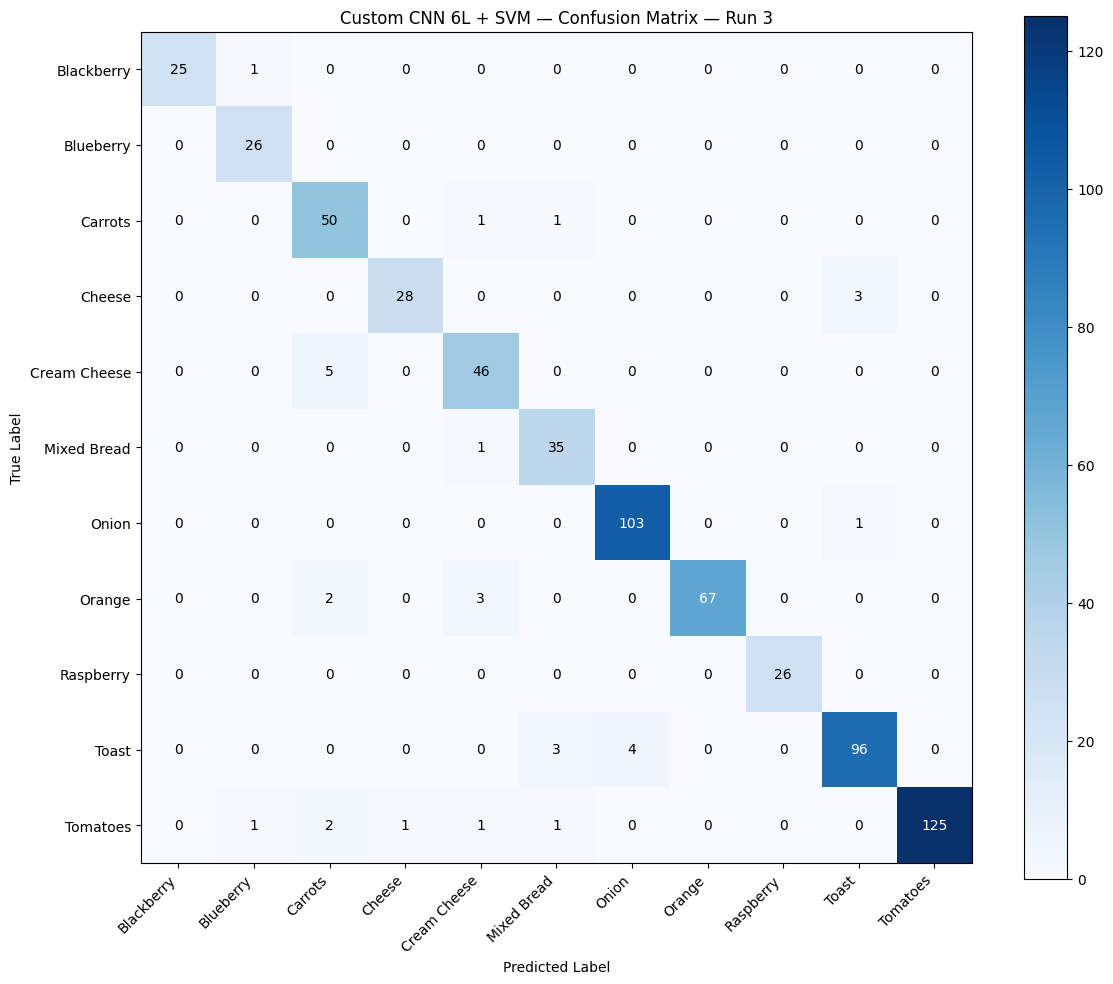

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_confusion_matrix_run3.png


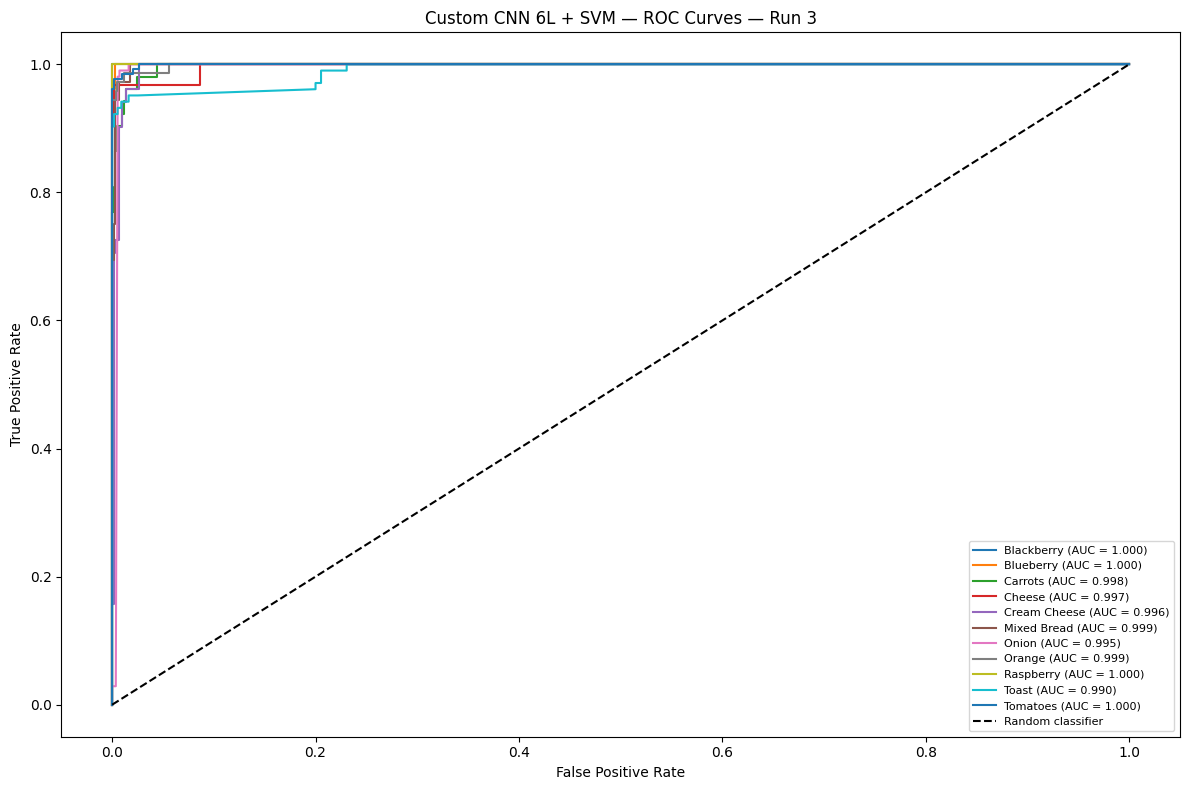

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_roc_curves_run3.png


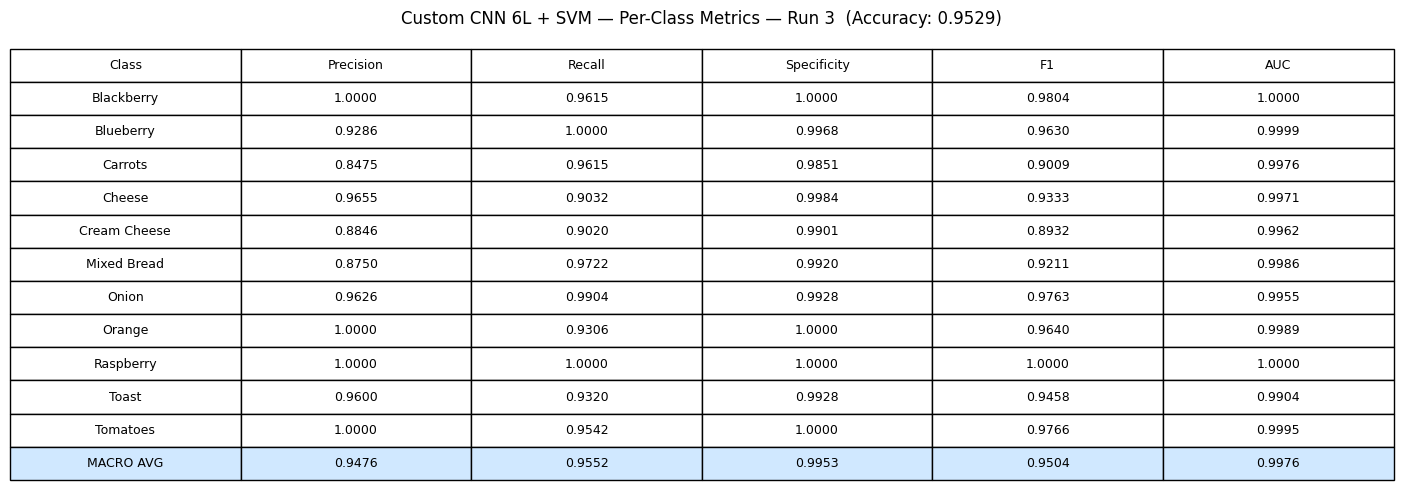

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_metrics_table_run3.png

  RUN 4 / 5  —  Custom CNN 6L + SVM
  CNN checkpoint : custom_cnn_run4_best.keras
  SVM seed       : 123

  Loading checkpoint : custom_cnn_run4_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9703
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training SVM on CNN run 4 features...
  ✓ Training complete

  Run 4 Results
    CNN val_acc  : 0.9703
    SVM Accuracy : 0.9757
    Precision    : 0.9767
    Recall       : 0.9796
    Specificity  : 0.9975
    F1 Score     : 0.9778
    Mean AUC     : 0.9984


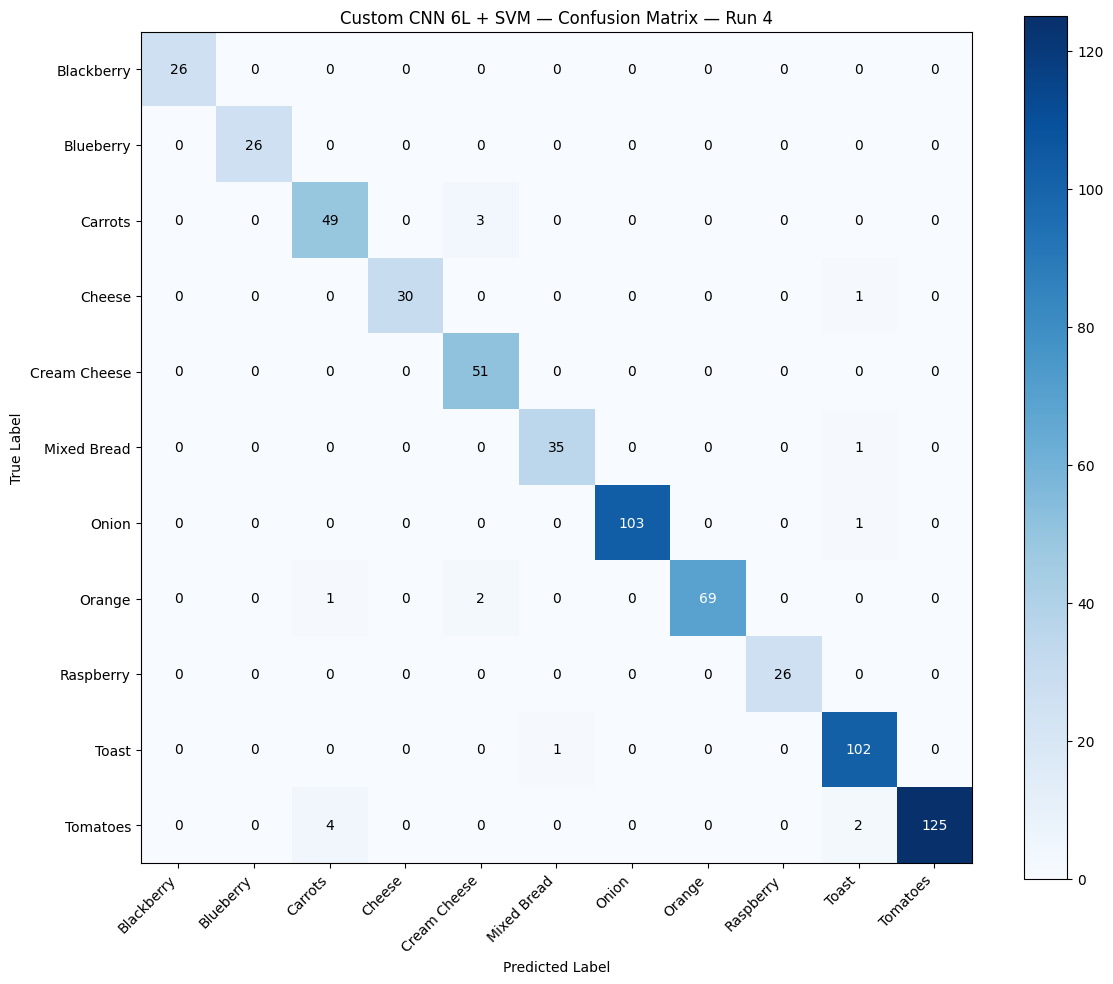

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_confusion_matrix_run4.png


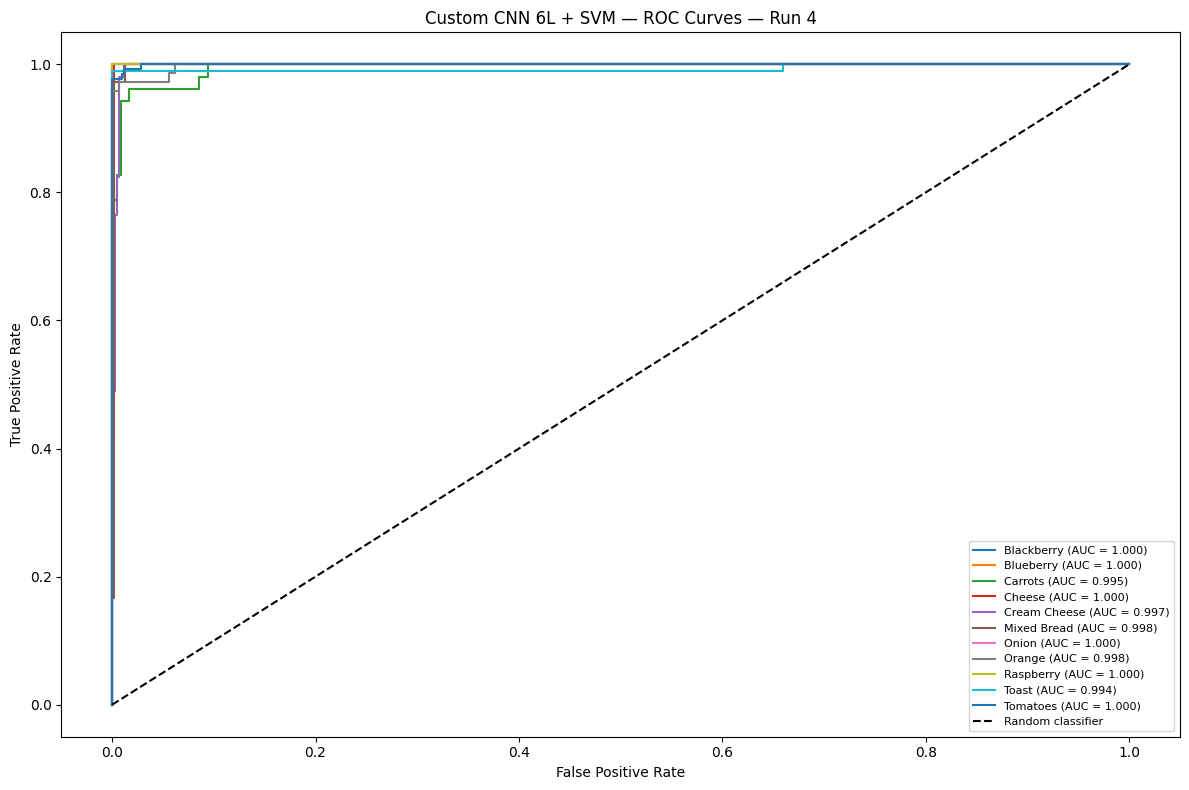

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_roc_curves_run4.png


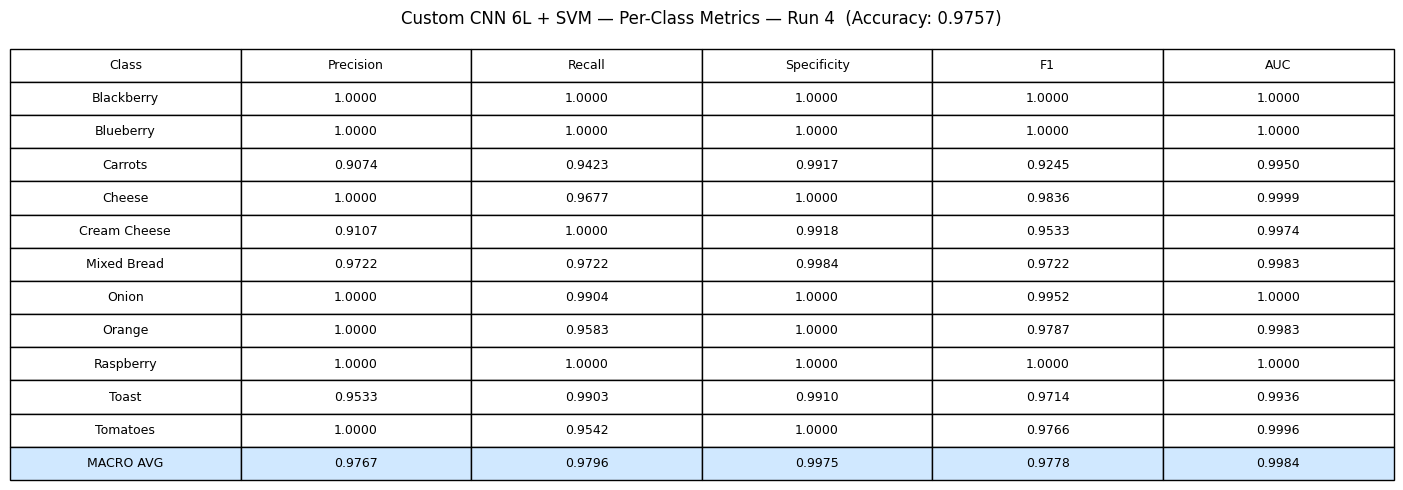

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_metrics_table_run4.png

  RUN 5 / 5  —  Custom CNN 6L + SVM
  CNN checkpoint : custom_cnn_run5_best.keras
  SVM seed       : 256

  Loading checkpoint : custom_cnn_run5_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9672
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training SVM on CNN run 5 features...
  ✓ Training complete

  Run 5 Results
    CNN val_acc  : 0.9672
    SVM Accuracy : 0.9635
    Precision    : 0.9632
    Recall       : 0.9621
    Specificity  : 0.9963
    F1 Score     : 0.9622
    Mean AUC     : 0.9990


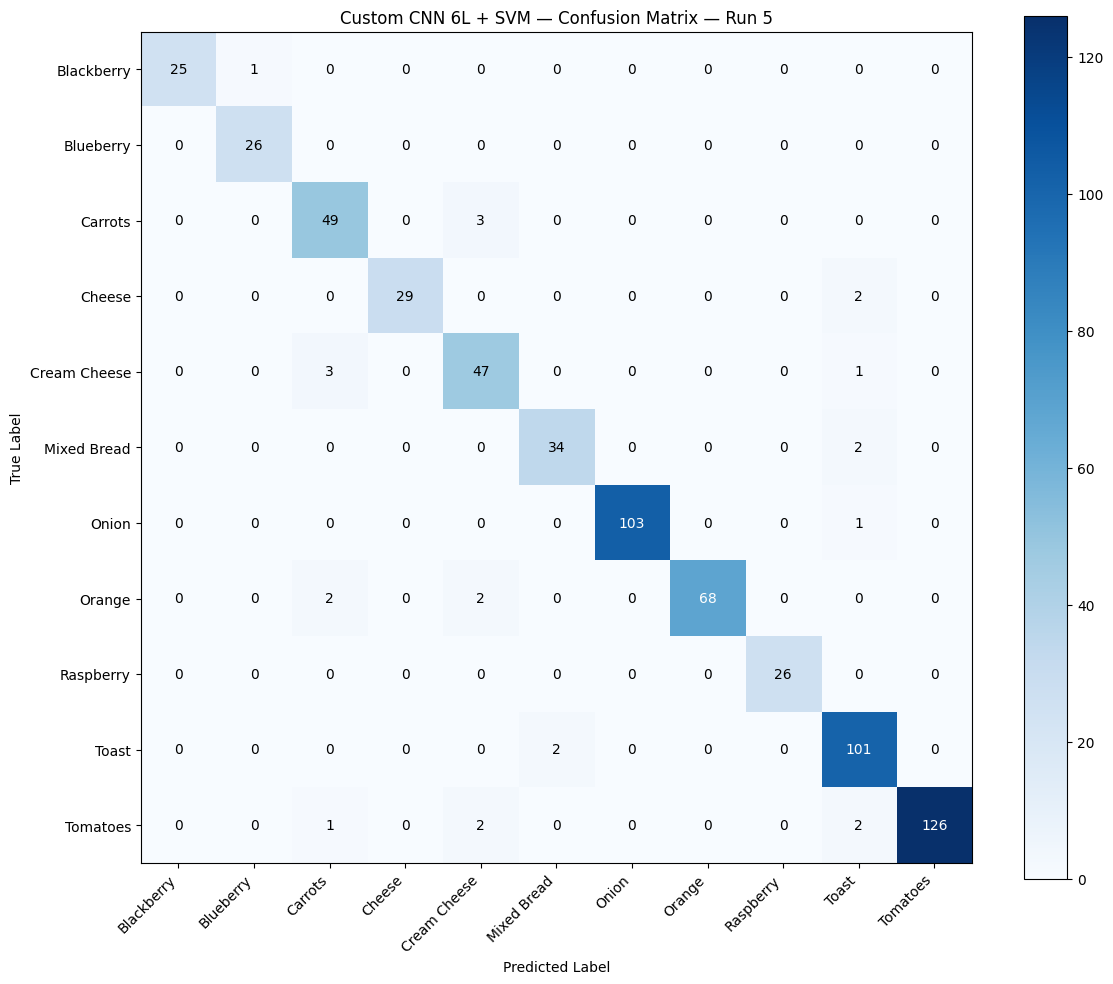

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_confusion_matrix_run5.png


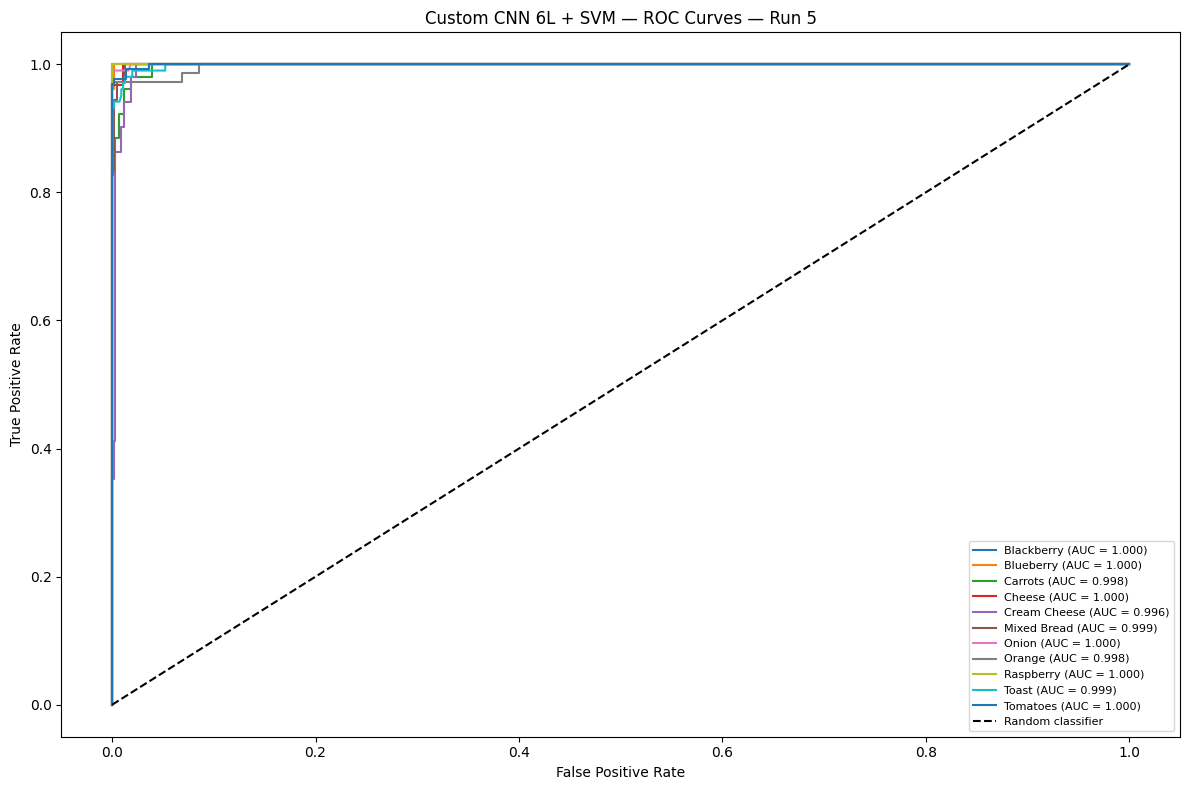

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_roc_curves_run5.png


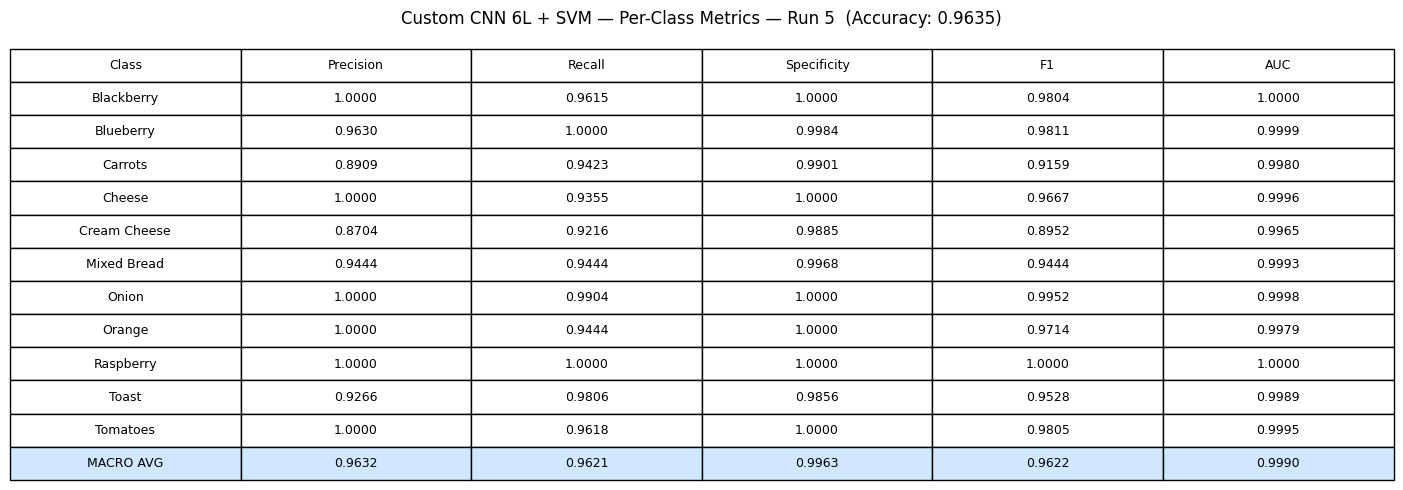

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_svm\custom_cnn6_svm_metrics_table_run5.png

  PER-RUN RESULTS — Custom CNN 6L + SVM
  Run     CNN ValAcc    Test Acc   Precision Sensitivity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────
  1           0.9656      0.9620      0.9584      0.9615    0.9597    0.9986
  2           0.6234      0.6125      0.7076      0.7016    0.6697    0.9163
  3           0.9578      0.9529      0.9476      0.9552    0.9504    0.9976
  4           0.9703      0.9757      0.9767      0.9796    0.9778    0.9984
  5           0.9672      0.9635      0.9632      0.9621    0.9622    0.9990
──────────────────────────────────────────────────────────────────────────────────

──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric              Mean       Std       Min       Max              95% CI
────────────────────────────────────────────────────────────────────────────

In [28]:
"""
Fragment 3 — SVM Classification on Custom CNN 6L Features (5 Runs)
===================================================================
Custom CNN 6L Hybrid Pipeline — Feature Extraction + SVM Classification

- Loads Custom CNN 6L extracted features from disk
- Each run uses features extracted from a different CNN checkpoint
- Run 1 uses CNN run1 features, Run 2 uses CNN run2 features etc.
- This reflects genuine variance from 5 independent CNN trainings
- Evaluates on test features — never seen during training
- Computes full metrics + 95% confidence intervals
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "custom_cnn6_svm")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs(PLOT_DIR, exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"
SVM_C      = 1.0
SVM_GAMMA  = "scale"

# ── Step 1: Helper — extract features from a specific CNN checkpoint ──────────

def extract_run_features(run_idx):
    """
    Loads CNN 6L checkpoint for run_idx, extracts features
    from train and test sets. Each run gets its own feature
    set reflecting that run's learned representations.
    """

    ckpt_name = f"custom_cnn_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    print(f"  Loading checkpoint : {ckpt_name}")
    full_model = tf.keras.models.load_model(ckpt_path)

    # Build feature extractor — tap Dense(128)
    extractor = Model(
        inputs  = full_model.input,
        outputs = full_model.get_layer("dense_128").output,
        name    = f"cnn6_extractor_run{run_idx}"
    )
    extractor.trainable = False

    # Build fresh generators — shuffle=False for alignment
    train_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    train_gen       = train_datagen.flow_from_directory(
        AUG_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    test_datagen    = ImageDataGenerator(rescale=1.0 / 255)
    test_gen        = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    # Extract features
    train_gen.reset()
    X_tr = extractor.predict(
        train_gen,
        steps   = np.ceil(train_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_tr = train_gen.classes

    test_gen.reset()
    X_te = extractor.predict(
        test_gen,
        steps   = np.ceil(test_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_te = test_gen.classes

    # Get val accuracy from CSV log for reporting
    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR, "custom_cnn_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR, f"custom_cnn_run{run_idx}_log.csv")

    val_acc = float("nan")
    if os.path.exists(csv_path):
        log     = pd.read_csv(csv_path)
        val_acc = max(log["val_accuracy"])

    class_names = list(train_gen.class_indices.keys())

    print(f"  CNN val_accuracy   : {val_acc:.4f}")
    print(f"  X_train shape      : {X_tr.shape}")
    print(f"  X_test  shape      : {X_te.shape}")

    return X_tr, y_tr, X_te, y_te, val_acc, class_names

# ── Step 2: Helper — compute metrics ─────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob, class_names):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    specificities = []
    num_classes   = len(class_names)
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    roc_auc    = {}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, class_names, save_dir):
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(n),
        yticks      = np.arange(n),
        xticklabels = class_names,
        yticklabels = class_names,
        title       = f"Custom CNN 6L + SVM — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_svm_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))
    for cls in class_names:
        ax.plot(roc_auc[cls]["fpr"], roc_auc[cls]["tpr"],
                label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"Custom CNN 6L + SVM — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_svm_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")
    rows = []
    for i, cls in enumerate(class_names):
        cm   = metrics["cm"]
        tp   = cm[i, i]
        fp   = cm[:, i].sum() - tp
        fn   = cm[i, :].sum() - tp
        tn   = cm.sum() - tp - fp - fn
        prec = tp / (tp + fp + 1e-7)
        rec  = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        f1   = 2 * prec * rec / (prec + rec + 1e-7)
        rows.append([cls, f"{prec:.4f}", f"{rec:.4f}",
                     f"{spec:.4f}", f"{f1:.4f}",
                     f"{metrics['roc_auc'][cls]['auc']:.4f}"])
    rows.append([
        "MACRO AVG",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in class_names]):.4f}",
    ])
    table = ax.table(
        cellText  = rows,
        colLabels = ["Class", "Precision", "Recall",
                     "Specificity", "F1", "AUC"],
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)
    for j in range(6):
        table[len(rows), j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"Custom CNN 6L + SVM — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_svm_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

# ── Step 3: 5-Run Loop — each run uses its own CNN checkpoint ─────────────────

print("=" * 60)
print("  Fragment 3 — Custom CNN 6L + SVM  (5 Runs)")
print("=" * 60)
print(f"  Design         : each run uses its own CNN checkpoint")
print(f"  Feature source : Dense(128) from custom_cnn_run{{N}}_best.keras")
print(f"  Kernel         : {SVM_KERNEL}")
print(f"  C              : {SVM_C}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  Custom CNN 6L + SVM")
    print(f"  CNN checkpoint : custom_cnn_run{run_idx}_best.keras")
    print(f"  SVM seed       : {seed}")
    print(f"{'='*60}\n")

    # ── Extract features from this run's CNN checkpoint ───────────────────────
    X_tr, y_tr, X_te, y_te, cnn_val_acc, class_names = \
        extract_run_features(run_idx)

    NUM_CLASSES = len(class_names)
    CLASS_NAMES = class_names

    # ── Shuffle train features with this run's seed ───────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_tr))
    X_tr    = X_tr[indices]
    y_tr    = y_tr[indices]

    # ── Scale features ────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # ── Train SVM ─────────────────────────────────────────────────────────────
    print(f"\n  Training SVM on CNN run {run_idx} features...")
    svm = SVC(
        kernel       = SVM_KERNEL,
        C            = SVM_C,
        gamma        = SVM_GAMMA,
        probability  = True,
        random_state = seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)

    metrics         = compute_metrics(y_te, y_pred, y_prob, class_names)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    mean_auc = np.mean([metrics["roc_auc"][c]["auc"] for c in class_names])

    all_run_results.append({
        "run"          : run_idx,
        "seed"         : seed,
        "cnn_val_acc"  : cnn_val_acc,
        "accuracy"     : metrics["accuracy"],
        "precision"    : metrics["precision"],
        "recall"       : metrics["recall"],
        "specificity"  : metrics["specificity"],
        "f1"           : metrics["f1"],
        "mean_auc"     : mean_auc,
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    CNN val_acc  : {cnn_val_acc:.4f}")
    print(f"    SVM Accuracy : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Recall       : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    Mean AUC     : {mean_auc:.4f}")

    plot_confusion_matrix(metrics["cm"],  run_idx, class_names, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],   run_idx, class_names, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, class_names, PLOT_DIR)

# ── Step 4: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_cnn  = 12
col_test = 12
col_prec = 12
col_sens = 12
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_cnn + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_cnn + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — Custom CNN 6L + SVM")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'CNN ValAcc':>{col_cnn}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['cnn_val_acc']:>{col_cnn}.4f}"
        f"{r['accuracy']:>{col_test}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['mean_auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 5: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "CNN Val Acc": [r["cnn_val_acc"] for r in all_run_results],
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["mean_auc"]    for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 6: Expose for comparison ─────────────────────────────────────────────

custom_cnn6_svm_all_metrics     = all_metrics
custom_cnn6_svm_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 3 complete.")
print(f"     custom_cnn6_svm_all_metrics and "
      f"custom_cnn6_svm_all_run_results ready.")
print(f"     Proceed to Fragment 4 — KNN on Custom CNN 6L features.\n")

  Fragment 4 — Custom CNN 6L + KNN  (5 Runs)
  Design         : each run uses its own CNN checkpoint
  Feature source : Dense(128) from custom_cnn_run{N}_best.keras
  N Neighbours   : 5
  Metric         : euclidean
  Weights        : distance
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  Custom CNN 6L + KNN
  CNN checkpoint : custom_cnn_run1_best.keras
  KNN seed       : 27

  Loading checkpoint : custom_cnn_run1_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9656
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training KNN on CNN run 1 features...
  ✓ Training complete
  Predicting...

  Run 1 Results
    CNN val_acc  : 0.9656
    KNN Accuracy : 0.9635
    Precision    : 0.9589
    Recall       : 0.9637
    Specificity  : 0.9964
    F1 Score     : 0.9607
    Mean AUC     : 0.9895


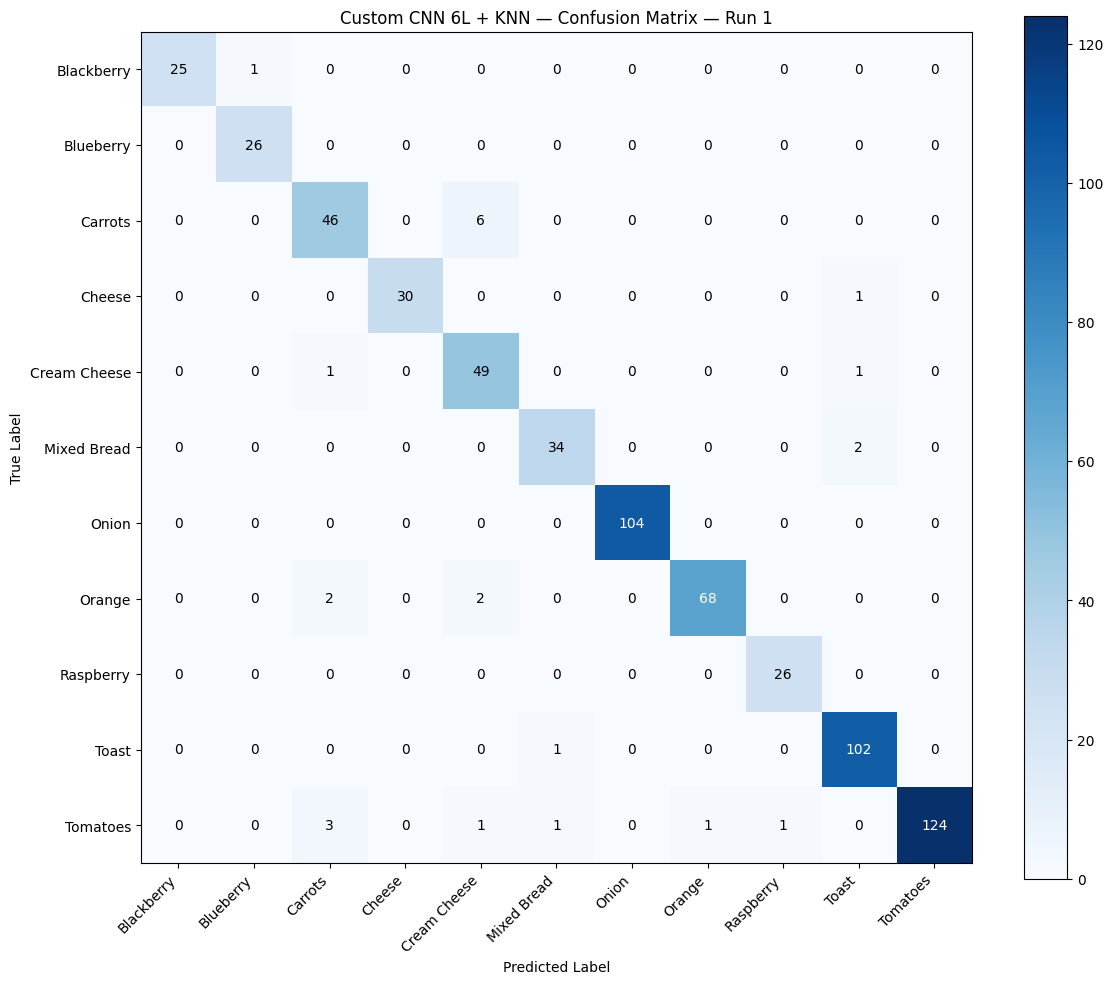

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_confusion_matrix_run1.png


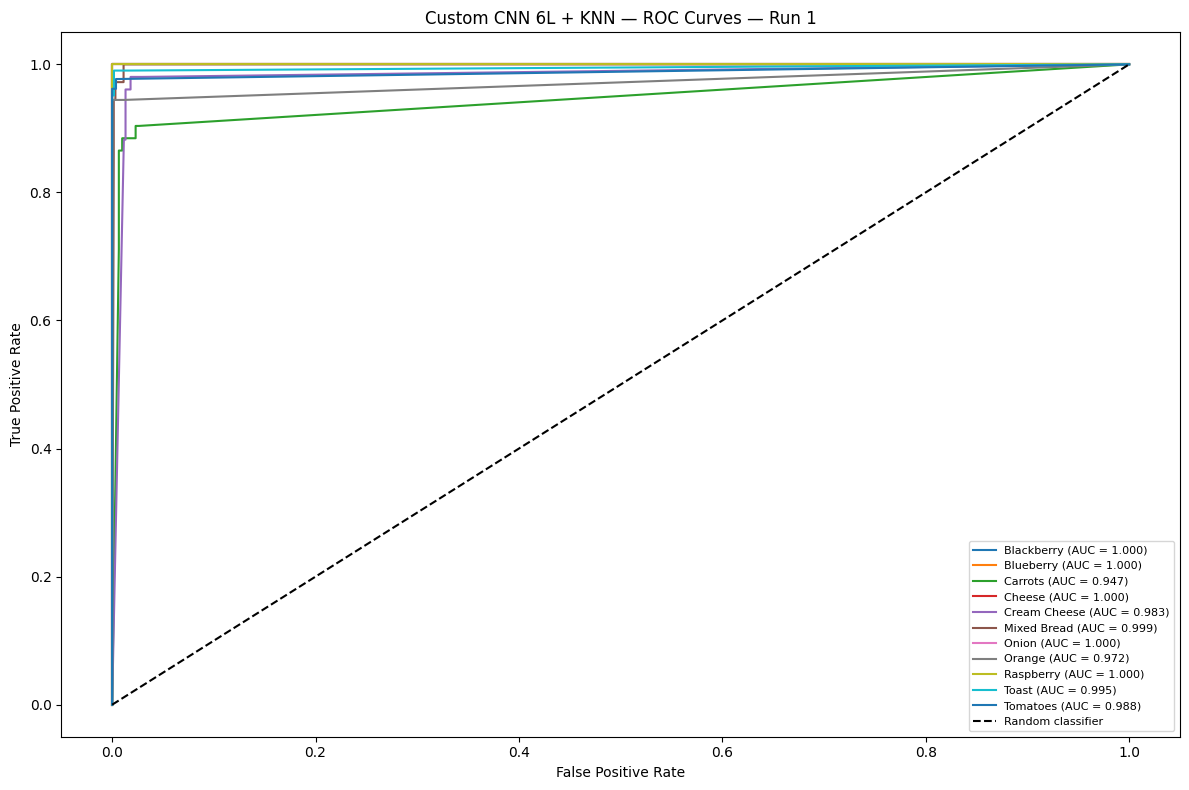

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_roc_curves_run1.png


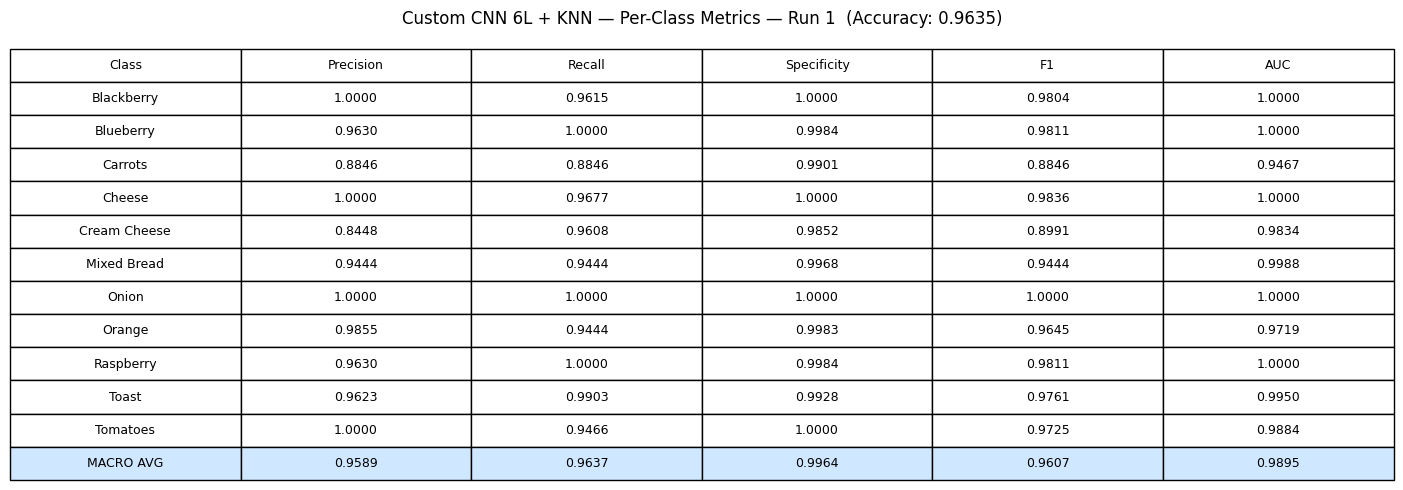

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_metrics_table_run1.png

  RUN 2 / 5  —  Custom CNN 6L + KNN
  CNN checkpoint : custom_cnn_run2_best.keras
  KNN seed       : 42

  Loading checkpoint : custom_cnn_run2_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.6234
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training KNN on CNN run 2 features...
  ✓ Training complete
  Predicting...

  Run 2 Results
    CNN val_acc  : 0.6234
    KNN Accuracy : 0.6064
    Precision    : 0.7034
    Recall       : 0.6961
    Specificity  : 0.9579
    F1 Score     : 0.6664
    Mean AUC     : 0.8781


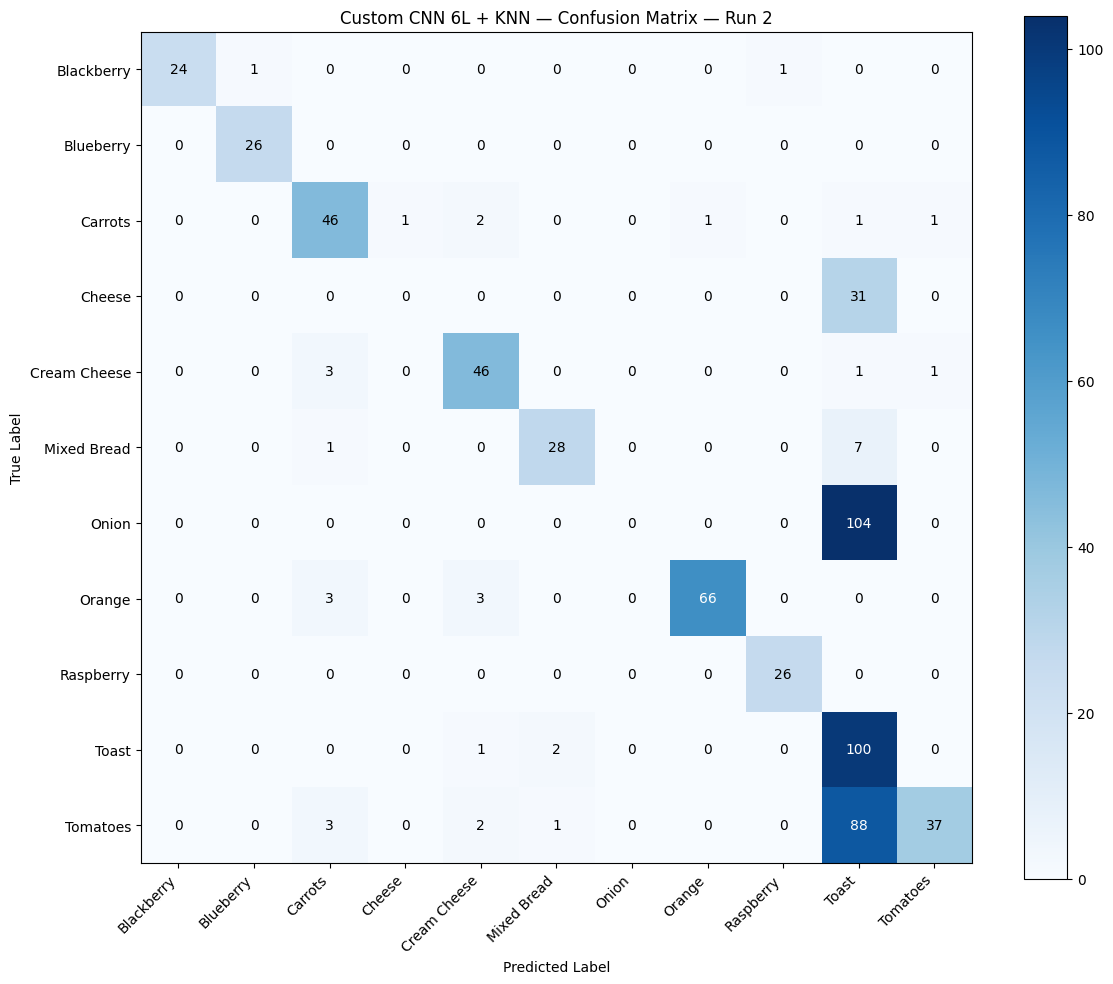

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_confusion_matrix_run2.png


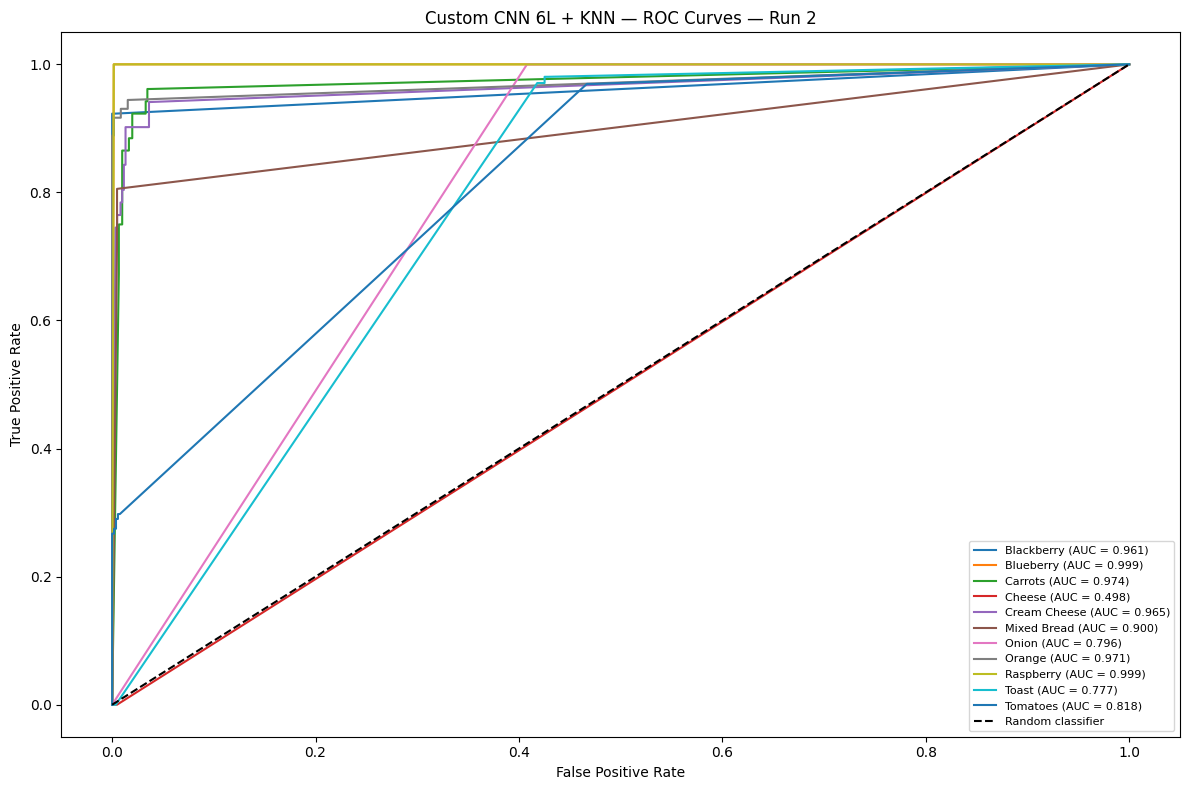

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_roc_curves_run2.png


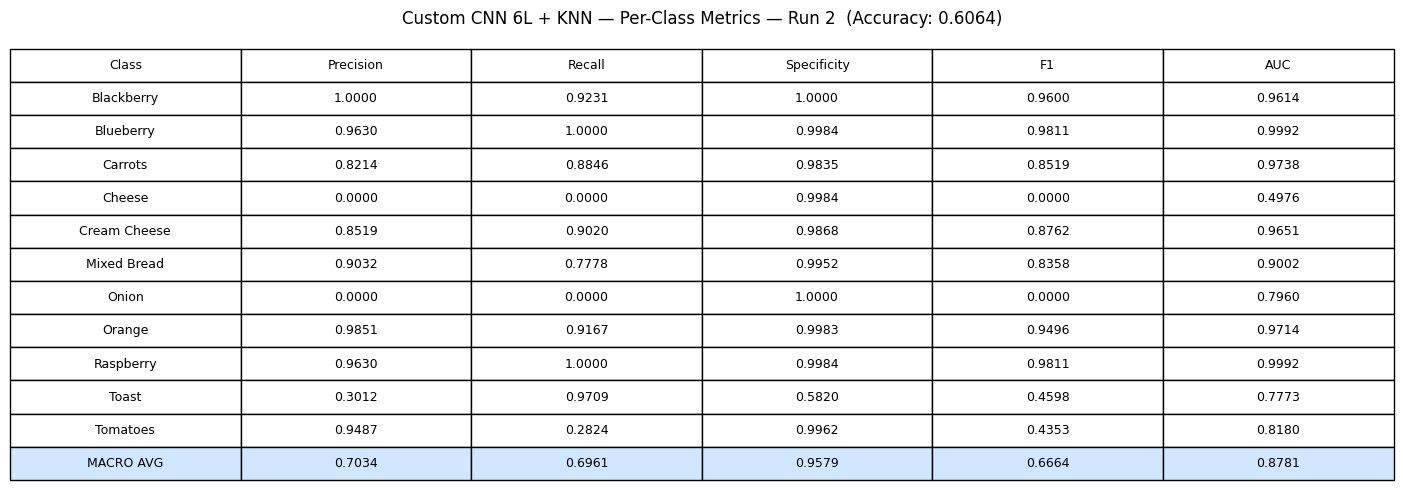

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_metrics_table_run2.png

  RUN 3 / 5  —  Custom CNN 6L + KNN
  CNN checkpoint : custom_cnn_run3_best.keras
  KNN seed       : 99

  Loading checkpoint : custom_cnn_run3_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9578
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training KNN on CNN run 3 features...
  ✓ Training complete
  Predicting...

  Run 3 Results
    CNN val_acc  : 0.9578
    KNN Accuracy : 0.9468
    Precision    : 0.9466
    Recall       : 0.9473
    Specificity  : 0.9946
    F1 Score     : 0.9462
    Mean AUC     : 0.9867


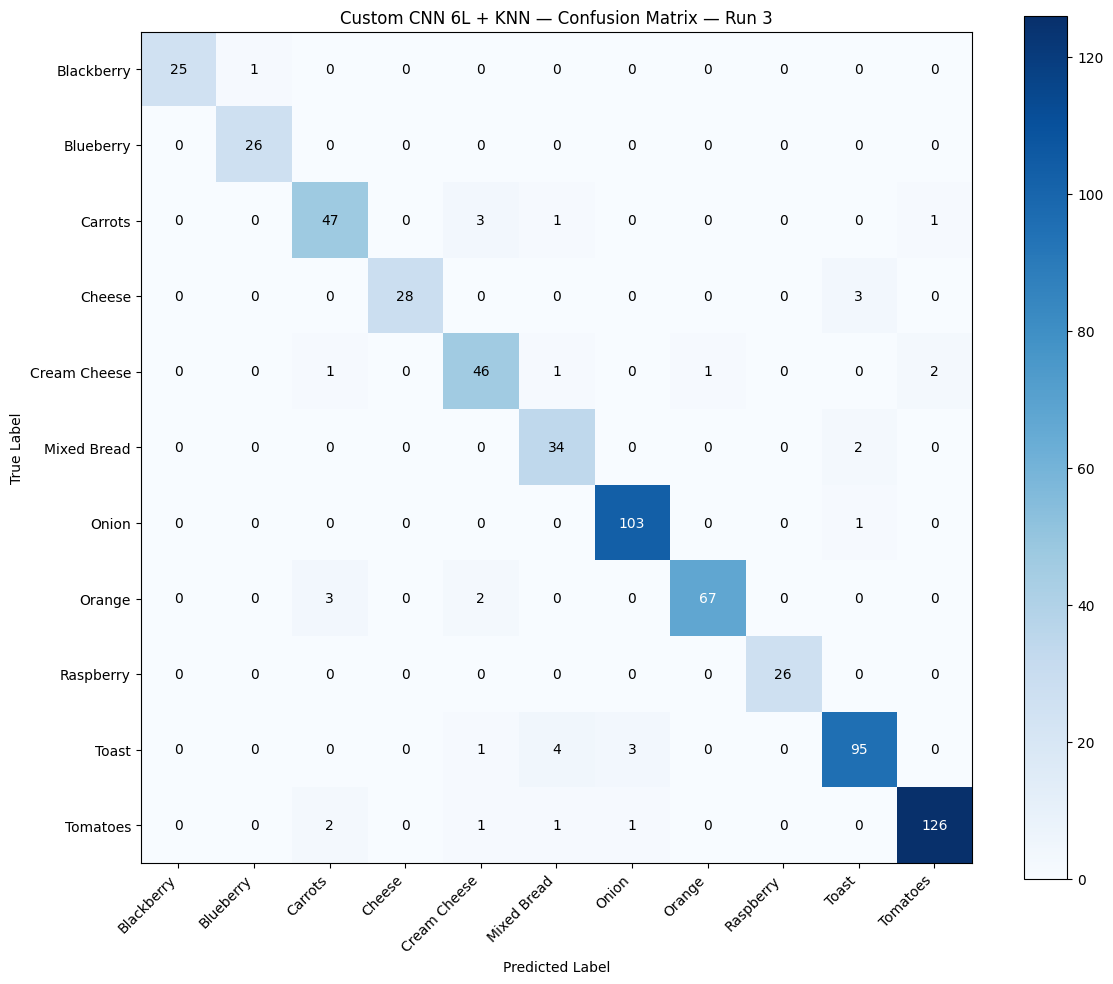

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_confusion_matrix_run3.png


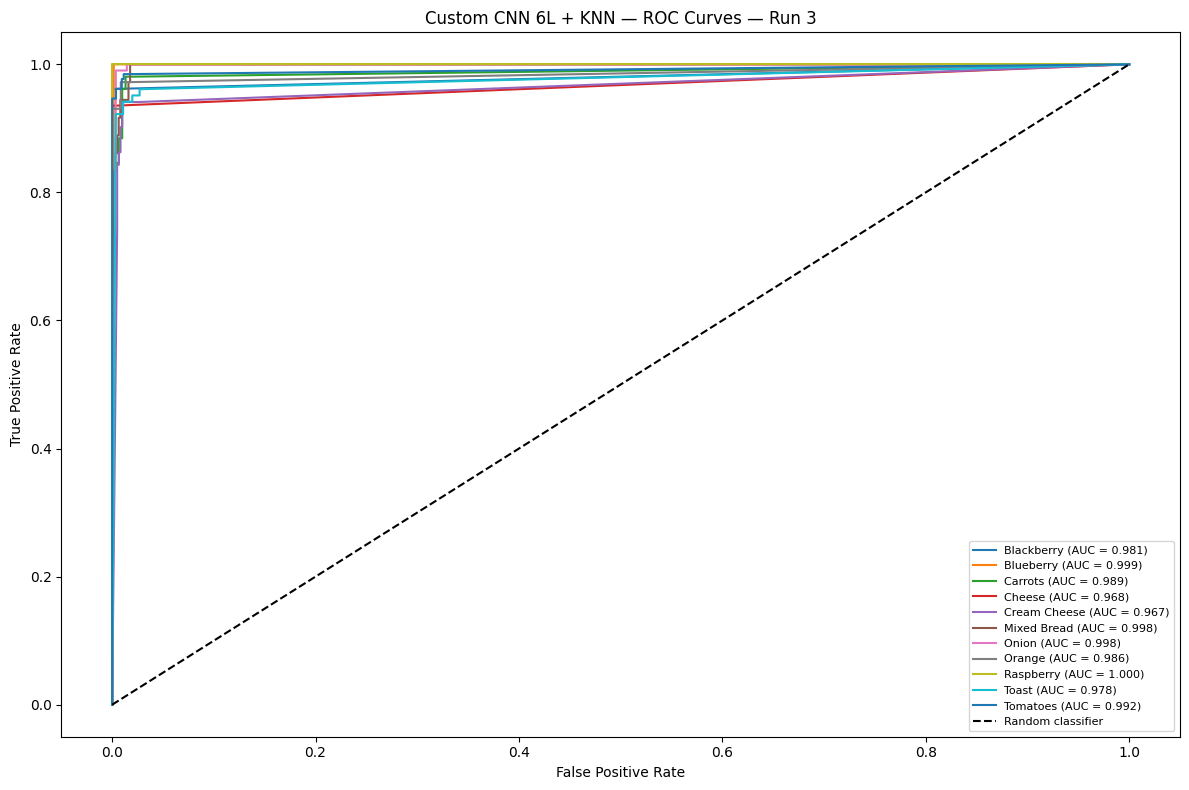

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_roc_curves_run3.png


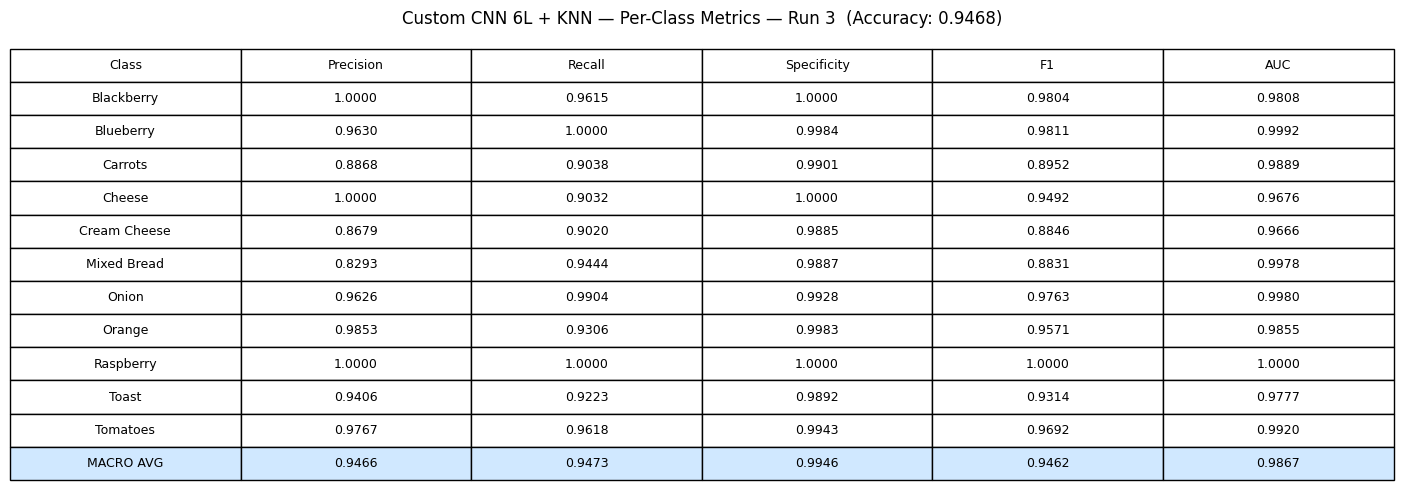

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_metrics_table_run3.png

  RUN 4 / 5  —  Custom CNN 6L + KNN
  CNN checkpoint : custom_cnn_run4_best.keras
  KNN seed       : 123

  Loading checkpoint : custom_cnn_run4_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9703
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training KNN on CNN run 4 features...
  ✓ Training complete
  Predicting...

  Run 4 Results
    CNN val_acc  : 0.9703
    KNN Accuracy : 0.9696
    Precision    : 0.9652
    Recall       : 0.9675
    Specificity  : 0.9970
    F1 Score     : 0.9654
    Mean AUC     : 0.9928


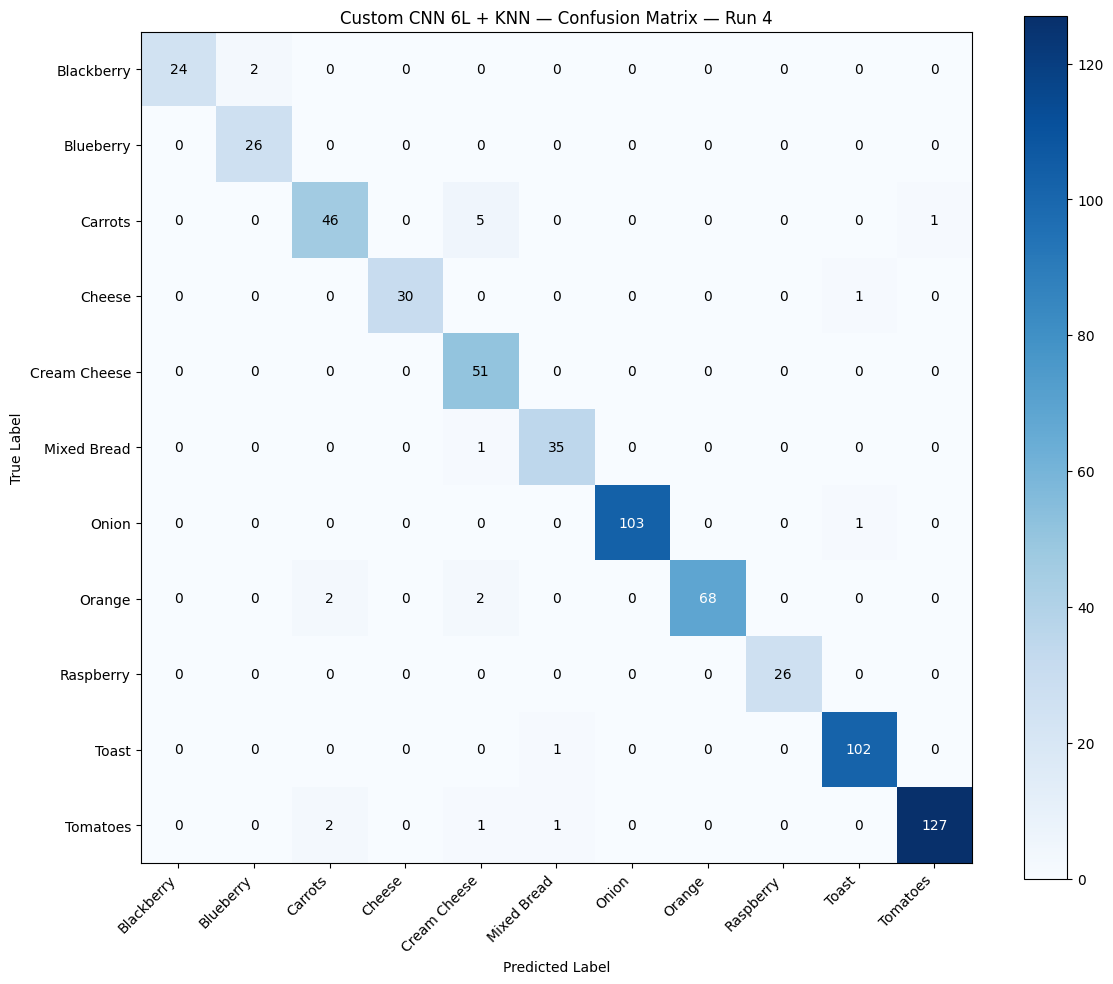

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_confusion_matrix_run4.png


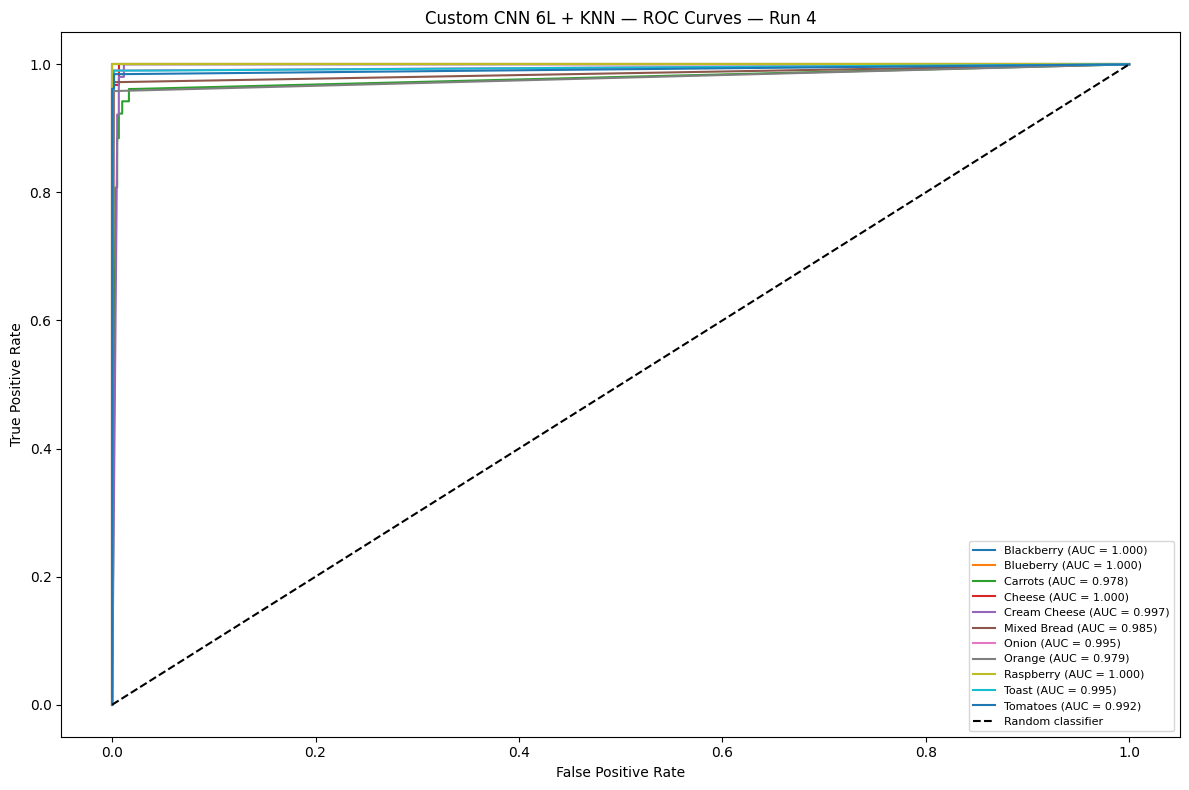

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_roc_curves_run4.png


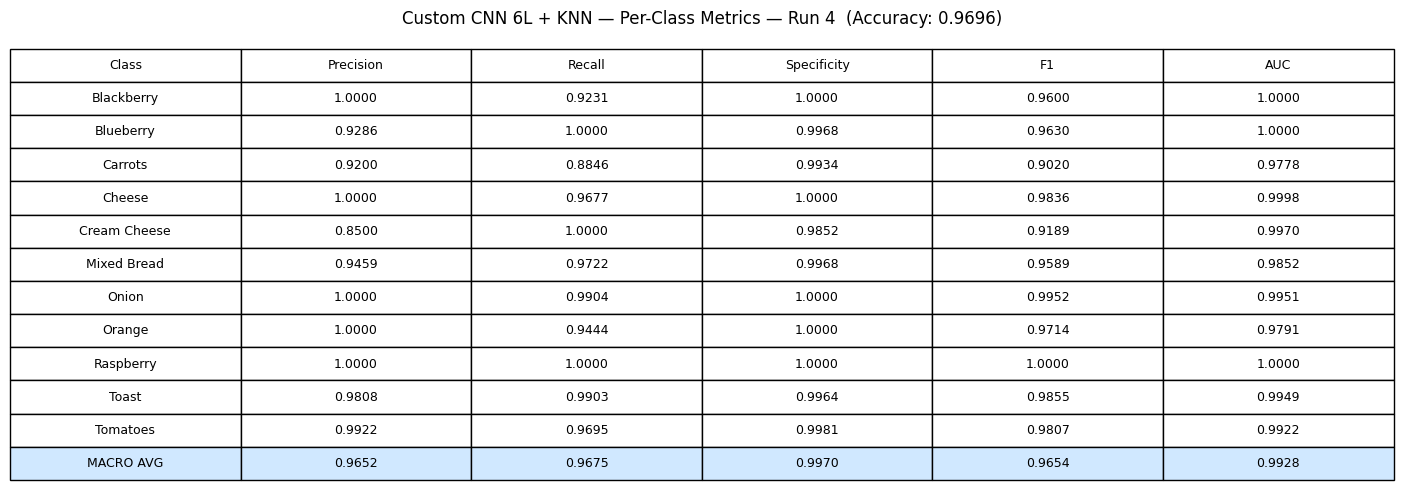

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_metrics_table_run4.png

  RUN 5 / 5  —  Custom CNN 6L + KNN
  CNN checkpoint : custom_cnn_run5_best.keras
  KNN seed       : 256

  Loading checkpoint : custom_cnn_run5_best.keras
Found 8833 images belonging to 11 classes.
Found 658 images belonging to 11 classes.
  CNN val_accuracy   : 0.9672
  X_train shape      : (8833, 128)
  X_test  shape      : (658, 128)

  Training KNN on CNN run 5 features...
  ✓ Training complete
  Predicting...

  Run 5 Results
    CNN val_acc  : 0.9672
    KNN Accuracy : 0.9605
    Precision    : 0.9586
    Recall       : 0.9588
    Specificity  : 0.9960
    F1 Score     : 0.9580
    Mean AUC     : 0.9922


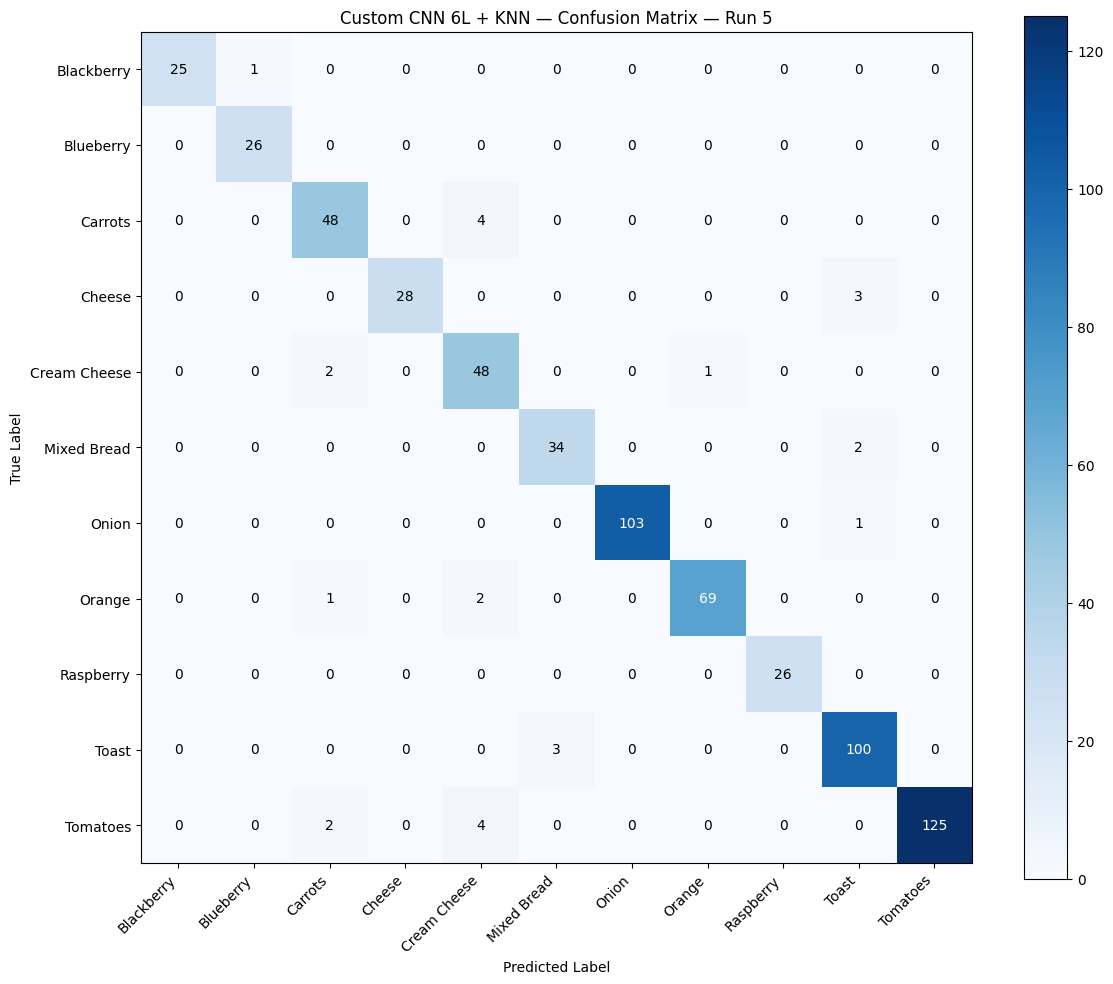

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_confusion_matrix_run5.png


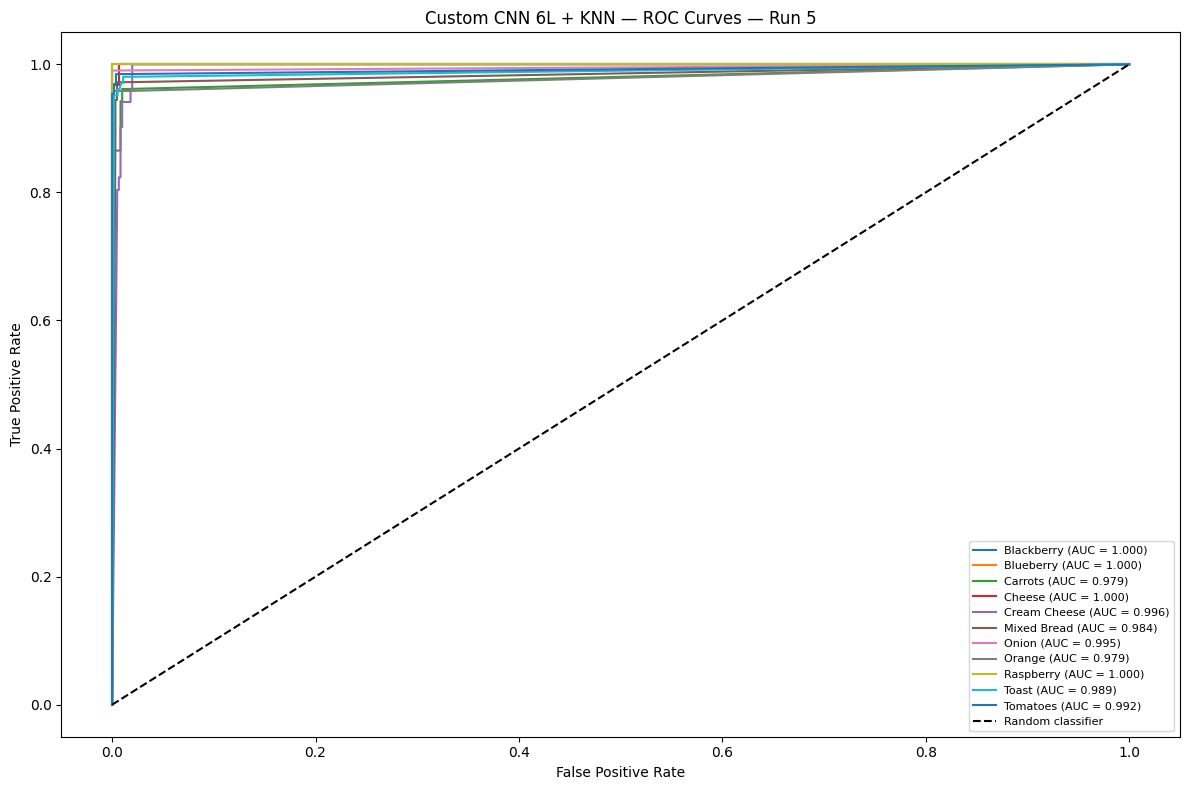

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_roc_curves_run5.png


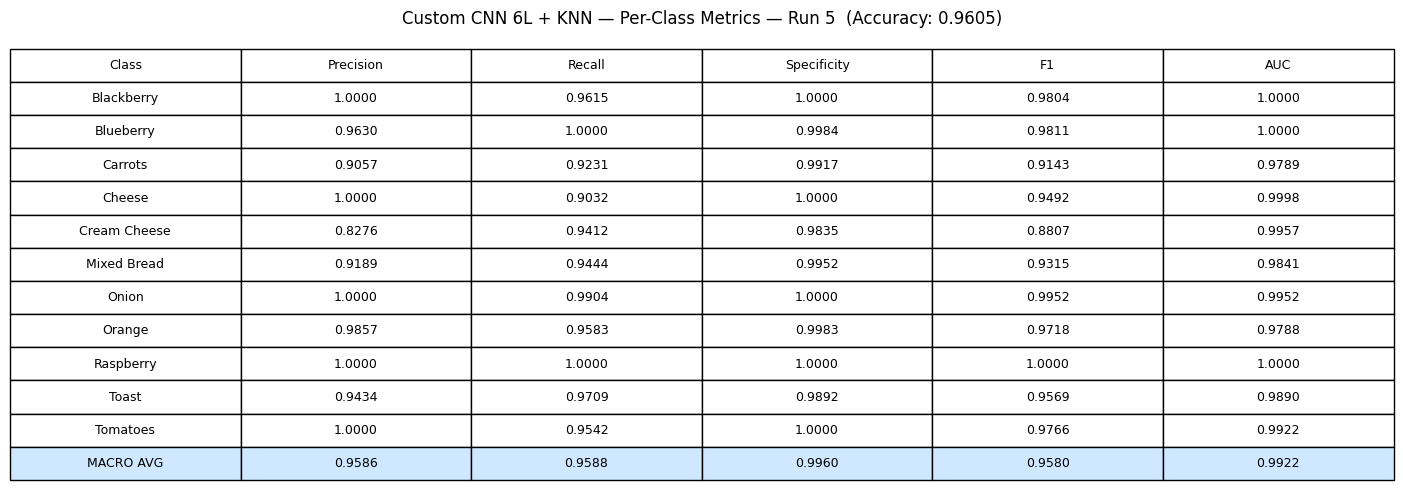

  Saved: D:\Mold Studies\Models\plots\custom_cnn6_knn\custom_cnn6_knn_metrics_table_run5.png

  PER-RUN RESULTS — Custom CNN 6L + KNN
  Run     CNN ValAcc    Test Acc   Precision Sensitivity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────
  1           0.9656      0.9635      0.9589      0.9637    0.9607    0.9895
  2           0.6234      0.6064      0.7034      0.6961    0.6664    0.8781
  3           0.9578      0.9468      0.9466      0.9473    0.9462    0.9867
  4           0.9703      0.9696      0.9652      0.9675    0.9654    0.9928
  5           0.9672      0.9605      0.9586      0.9588    0.9580    0.9922
──────────────────────────────────────────────────────────────────────────────────

──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric              Mean       Std       Min       Max              95% CI
────────────────────────────────────────────────────────────────────────────

In [29]:
"""
Fragment 4 — KNN Classification on Custom CNN 6L Features (5 Runs)
===================================================================
Custom CNN 6L Hybrid Pipeline — Feature Extraction + KNN Classification

- Each run loads its own CNN 6L checkpoint for feature extraction
- Run 1 uses CNN run1, Run 2 uses CNN run2 etc.
- This reflects genuine variance from 5 independent CNN trainings
- Evaluates on test features — never seen during training
- Computes full metrics + 95% confidence intervals
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "custom_cnn6_knn")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs(PLOT_DIR, exist_ok=True)

# ── KNN Parameters ────────────────────────────────────────────────────────────

KNN_N_NEIGHBORS = 5
KNN_METRIC      = "euclidean"
KNN_WEIGHTS     = "distance"

# ── Step 1: Helper — extract features from a specific CNN checkpoint ──────────

def extract_run_features(run_idx):
    """
    Loads CNN 6L checkpoint for run_idx, extracts features
    from train and test sets. Each run gets its own feature
    set reflecting that run's learned representations.
    """

    ckpt_name = f"custom_cnn_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    print(f"  Loading checkpoint : {ckpt_name}")
    full_model = tf.keras.models.load_model(ckpt_path)

    extractor = Model(
        inputs  = full_model.input,
        outputs = full_model.get_layer("dense_128").output,
        name    = f"cnn6_extractor_run{run_idx}"
    )
    extractor.trainable = False

    train_datagen = ImageDataGenerator(rescale=1.0 / 255)
    train_gen     = train_datagen.flow_from_directory(
        AUG_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    test_datagen  = ImageDataGenerator(rescale=1.0 / 255)
    test_gen      = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    train_gen.reset()
    X_tr = extractor.predict(
        train_gen,
        steps   = np.ceil(train_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_tr = train_gen.classes

    test_gen.reset()
    X_te = extractor.predict(
        test_gen,
        steps   = np.ceil(test_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_te = test_gen.classes

    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR, "custom_cnn_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR, f"custom_cnn_run{run_idx}_log.csv")

    val_acc = float("nan")
    if os.path.exists(csv_path):
        log     = pd.read_csv(csv_path)
        val_acc = max(log["val_accuracy"])

    class_names = list(train_gen.class_indices.keys())

    print(f"  CNN val_accuracy   : {val_acc:.4f}")
    print(f"  X_train shape      : {X_tr.shape}")
    print(f"  X_test  shape      : {X_te.shape}")

    return X_tr, y_tr, X_te, y_te, val_acc, class_names

# ── Step 2: Helper — compute metrics ─────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob, class_names):
    cm        = confusion_matrix(y_true, y_pred)
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    specificities = []
    num_classes   = len(class_names)
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    roc_auc    = {}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, class_names, save_dir):
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(n),
        yticks      = np.arange(n),
        xticklabels = class_names,
        yticklabels = class_names,
        title       = f"Custom CNN 6L + KNN — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_knn_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))
    for cls in class_names:
        ax.plot(roc_auc[cls]["fpr"], roc_auc[cls]["tpr"],
                label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"Custom CNN 6L + KNN — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_knn_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")
    rows = []
    for i, cls in enumerate(class_names):
        cm   = metrics["cm"]
        tp   = cm[i, i]
        fp   = cm[:, i].sum() - tp
        fn   = cm[i, :].sum() - tp
        tn   = cm.sum() - tp - fp - fn
        prec = tp / (tp + fp + 1e-7)
        rec  = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        f1   = 2 * prec * rec / (prec + rec + 1e-7)
        rows.append([cls, f"{prec:.4f}", f"{rec:.4f}",
                     f"{spec:.4f}", f"{f1:.4f}",
                     f"{metrics['roc_auc'][cls]['auc']:.4f}"])
    rows.append([
        "MACRO AVG",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in class_names]):.4f}",
    ])
    table = ax.table(
        cellText  = rows,
        colLabels = ["Class", "Precision", "Recall",
                     "Specificity", "F1", "AUC"],
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)
    for j in range(6):
        table[len(rows), j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"Custom CNN 6L + KNN — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"custom_cnn6_knn_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

# ── Step 3: 5-Run Loop — each run uses its own CNN checkpoint ─────────────────

print("=" * 60)
print("  Fragment 4 — Custom CNN 6L + KNN  (5 Runs)")
print("=" * 60)
print(f"  Design         : each run uses its own CNN checkpoint")
print(f"  Feature source : Dense(128) from custom_cnn_run{{N}}_best.keras")
print(f"  N Neighbours   : {KNN_N_NEIGHBORS}")
print(f"  Metric         : {KNN_METRIC}")
print(f"  Weights        : {KNN_WEIGHTS}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  Custom CNN 6L + KNN")
    print(f"  CNN checkpoint : custom_cnn_run{run_idx}_best.keras")
    print(f"  KNN seed       : {seed}")
    print(f"{'='*60}\n")

    # ── Extract features from this run's CNN checkpoint ───────────────────────
    X_tr, y_tr, X_te, y_te, cnn_val_acc, class_names = \
        extract_run_features(run_idx)

    NUM_CLASSES = len(class_names)
    CLASS_NAMES = class_names

    # ── Shuffle train features with this run's seed ───────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_tr))
    X_tr    = X_tr[indices]
    y_tr    = y_tr[indices]

    # ── Scale features ────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # ── Train KNN ─────────────────────────────────────────────────────────────
    print(f"\n  Training KNN on CNN run {run_idx} features...")
    knn = KNeighborsClassifier(
        n_neighbors = KNN_N_NEIGHBORS,
        metric      = KNN_METRIC,
        weights     = KNN_WEIGHTS,
        n_jobs      = -1,
    )
    knn.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Predict ───────────────────────────────────────────────────────────────
    print(f"  Predicting...")
    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)

    metrics         = compute_metrics(y_te, y_pred, y_prob, class_names)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    mean_auc = np.mean([metrics["roc_auc"][c]["auc"] for c in class_names])

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "cnn_val_acc": cnn_val_acc,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "mean_auc"   : mean_auc,
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    CNN val_acc  : {cnn_val_acc:.4f}")
    print(f"    KNN Accuracy : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Recall       : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    Mean AUC     : {mean_auc:.4f}")

    plot_confusion_matrix(metrics["cm"],  run_idx, class_names, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],   run_idx, class_names, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, class_names, PLOT_DIR)

# ── Step 4: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_cnn  = 12
col_test = 12
col_prec = 12
col_sens = 12
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_cnn + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_cnn + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — Custom CNN 6L + KNN")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'CNN ValAcc':>{col_cnn}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['cnn_val_acc']:>{col_cnn}.4f}"
        f"{r['accuracy']:>{col_test}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['mean_auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 5: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "CNN Val Acc": [r["cnn_val_acc"] for r in all_run_results],
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["mean_auc"]    for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 6: SVM vs KNN Comparison ─────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  Custom CNN 6L HYBRID — SVM vs KNN Comparison")
print(f"{'='*60}")
print(f"  {'Metric':<14} {'SVM Mean':>12} {'KNN Mean':>12} {'Winner':>10}")
print(f"  {'─'*50}")

comparison_metrics = {
    "Accuracy"   : "accuracy",
    "Precision"  : "precision",
    "Sensitivity": "recall",
    "Specificity": "specificity",
    "F1 Score"   : "f1",
    "AUC"        : "mean_auc",
}

for label, key in comparison_metrics.items():
    svm_mean = np.mean([r[key] for r in custom_cnn6_svm_all_run_results])
    knn_mean = np.mean([r[key] for r in all_run_results])
    winner   = "SVM" if svm_mean >= knn_mean else "KNN"
    print(
        f"  {label:<14}"
        f"{svm_mean:>12.4f}"
        f"{knn_mean:>12.4f}"
        f"{winner:>10}"
    )

print(f"{'='*60}")

# ── Step 7: Expose for cross-model comparison ─────────────────────────────────

custom_cnn6_knn_all_metrics     = all_metrics
custom_cnn6_knn_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     custom_cnn6_knn_all_metrics and "
      f"custom_cnn6_knn_all_run_results ready.")
print(f"     Proceed to Custom CNN 9L Hybrid pipeline.\n")

In [27]:
"""
Diagnostic — CNN 6L All 5 Runs Test Evaluation
================================================
Loads each of the 5 saved CNN 6L checkpoints and evaluates
on the test set to see how test accuracy correlates with
val accuracy across runs including the weak Run 2.
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies\Models"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
TOTAL_RUNS = 5

# ── Test generator ────────────────────────────────────────────────────────────

test_datagen   = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False,
)

CLASS_NAMES = list(test_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

# ── Evaluate all 5 runs ───────────────────────────────────────────────────────

print("=" * 60)
print("  CNN 6L — All 5 Runs Test Evaluation")
print("=" * 60)
print(f"  {'Run':<6} {'Val Acc':>10} {'Test Acc':>10} {'Checkpoint'}")
print(f"  {'─'*50}")

results = []

for run_idx in range(1, TOTAL_RUNS + 1):

    ckpt_name = f"custom_cnn_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    if not os.path.exists(ckpt_path):
        print(f"  {run_idx:<6} {'N/A':>10} {'N/A':>10} {ckpt_name} — not found")
        continue

    # Load model
    model = tf.keras.models.load_model(ckpt_path)

    # Evaluate
    test_generator.reset()
    loss, test_acc = model.evaluate(
        test_generator,
        steps   = np.ceil(test_generator.samples / BATCH_SIZE),
        verbose = 0,
    )

    results.append({
        "run"      : run_idx,
        "test_acc" : test_acc,
        "ckpt"     : ckpt_name,
    })

    print(f"  {run_idx:<6} {'see log':>10} {test_acc:>10.4f} {ckpt_name}")

# ── Summary ───────────────────────────────────────────────────────────────────

print(f"\n  {'─'*50}")
best  = max(results, key=lambda x: x["test_acc"])
worst = min(results, key=lambda x: x["test_acc"])

print(f"  Best  : Run {best['run']}  — test_acc = {best['test_acc']:.4f}")
print(f"  Worst : Run {worst['run']} — test_acc = {worst['test_acc']:.4f}")
print(f"  Gap   : {best['test_acc'] - worst['test_acc']:.4f}")
print("=" * 60)

Found 658 images belonging to 11 classes.
  CNN 6L — All 5 Runs Test Evaluation
  Run       Val Acc   Test Acc Checkpoint
  ──────────────────────────────────────────────────
  1         see log     0.9286 custom_cnn_run1_best.keras
  2         see log     0.5988 custom_cnn_run2_best.keras
  3         see log     0.9483 custom_cnn_run3_best.keras
  4         see log     0.9726 custom_cnn_run4_best.keras
  5         see log     0.9605 custom_cnn_run5_best.keras

  ──────────────────────────────────────────────────
  Best  : Run 4  — test_acc = 0.9726
  Worst : Run 2 — test_acc = 0.5988
  Gap   : 0.3739
